# Análisis Exploratorio de Datos (EDA) y Preprocesamiento de Datos para Machine Learning

**Fecha:** Septiembre 2026  
**Dataset:** Telco Customer Churn (IBM Sample Data Sets)  
**Autor:** Proyecto de Ciencia de Datos  

---

## 1. Descripción de las Fuentes de Datos e Introducción

El dataset **Telco Customer Churn** fue creado originalmente por **IBM (International Business Machines)** como parte de su repositorio de "Sample Data Sets" de Watson Analytics, diseñado específicamente para demostrar técnicas de análisis predictivo y programas de retención de clientes. Fue publicado oficialmente en el blog de IBM Community por **Steven Macko** en **2019**.

### Contexto y Origen de los Datos
*   **Creador:** IBM (International Business Machines)
*   **Año de publicación:** 2019
*   **País de origen:** Estados Unidos (representando una empresa ficticia de telecomunicaciones ubicada en el estado de California)
*   **Naturaleza de los datos:** **Datos simulados**. Es importante aclarar que no corresponden a clientes reales de una empresa existente, sino que son datos sintéticos balanceados educativamente para emular un escenario de negocio real.
*   **Fuentes de referencia:**
    *   *Fuente Original (IBM):* [IBM Community Blog - Steven Macko (2019)](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113)
    *   *Repositorio en Kaggle:* [Telco Customer Churn (blastchar)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

### Descripción Estructural del Dataset
*   **Cantidad de registros:** 7,043 clientes (filas).
*   **Cantidad de variables:** 21 (20 variables de características demográficas, de servicios y de cuentas financieras, y 1 variable objetivo).
*   **Variable objetivo (Target):** `Churn` (Binaria: `Yes` / `No`).
*   **Distribución de clases (Desbalance):** ~73.5% No abandona (`No`) / ~26.5% Sí abandona (`Yes`).

### Trabajos Previos, Origen y Conclusiones Académicas
Este conjunto de datos es una referencia clásica en la enseñanza del aprendizaje supervisado. La base se originó como un dataset sintético y educativo de IBM, y posteriormente fue difundido masivamente en Kaggle por la comunidad de `blastchar`, donde se convirtió en un benchmark muy usado para comparar modelos de clasificación orientados a retención de clientes.

Los estudios y repositorios que usan este dataset coinciden en que la problemática real no es solo predecir la salida, sino entender qué variables son más útiles para explicar el abandono. En la práctica, la investigación previa muestra que:

*   **IBM** desarrolló y difundió esta muestra para ilustrar análisis de retención en servicios digitales y telecomunicaciones.
*   **El dataset es sintético**, no corresponde a clientes reales de una compañía determinada, pero reproduce patrones de comportamiento observables en empresas de telecomunicaciones.
*   **La base se publicó alrededor de 2019** y se usa como ejemplo de modelado predictivo en educación, benchmarking y análisis de churn comercial.
*   **El patrón de negocio más repetido** es que el riesgo de abandono crece cuando el cliente es nuevo, paga mensualmente y usa servicios premium con contratos flexibles.

#### Modelos de mejor rendimiento reportados habitualmente:
*   **Random Forest:** Logra una exactitud (*Accuracy*) cercana al ~80% y un *Recall* de ~75%, con un AUC-ROC aproximado de 0.84.
*   **Gradient Boosting (XGBoost / LightGBM):** Suele rondar el ~79% de exactitud, mostrando buena capacidad para manejar variables categóricas y relaciones no lineales.
*   **Regresión Logística y SVM:** Mantienen resultados estables con AUC-ROC aproximado de 0.84, y suelen servir como líneas base muy útiles para comparar modelos más complejos.

#### Variables críticas identificadas en estudios previos:
1.  **Contract (Tipo de Contrato):** Los clientes con contratos mensuales presentan una tasa de abandono mucho mayor que quienes tienen acuerdos anuales o bianuales.
2.  **tenure (Antigüedad):** El riesgo de abandono es mayor en los clientes con menos de 12 meses de permanencia, y se reduce claramente a medida que aumenta la antigüedad.
3.  **MonthlyCharges (Cargos Mensuales):** Los clientes con mayores cargos mensuales tienen más probabilidades de cancelar, principalmente por fricción de precio o percepción de valor.
4.  **InternetService (Fibra Óptica):** El servicio de fibra suele asociarse a tasas de abandono elevadas, probablemente por mayor sensibilidad a problemas de servicio y calidad percibida.
5.  **OnlineSecurity / TechSupport:** La falta de servicios complementarios y soporte técnico está asociada a mayor rotación.

*   **Objetivo de Modelado:** Preparar y transformar de manera transparente las variables para un posterior modelo de clasificación binaria supervisado, previniendo activamente el *Data Leakage* mediante el aislamiento temprano del conjunto de datos en entrenamiento (*Train*) y validación (*Test*).

#### Conclusión interpretativa del contexto del dataset

En términos de negocio, este conjunto de datos permite concluir que el abandono no aparece como un fenómeno aleatorio, sino como un riesgo concentrado en clientes recién incorporados, con contratos flexibles y con una percepción de valor menor. Eso hace que el análisis predictivo sea útil para diseñar campañas de retención, renovaciones tempranas y segmentación de riesgo.

## 1.1. Objetivos del Proyecto

*   **Objetivo Principal:** Analizar exhaustivamente el conjunto de datos para corregir sesgos e inconsistencias en el formateo de datos, proponer visualizaciones claras que respondan a las críticas metodológicas y estructurar un pipeline inicial robusto.
*   **Objetivo de Modelado:** Preparar y transformar de manera transparente las variables para un posterior modelo de clasificación binaria supervisado, previniendo activamente el *Data Leakage* mediante el aislamiento temprano del conjunto de datos en entrenamiento (*Train*) y validación (*Test*).

---

## 1.2. Diccionario de Referencia y Traducción de Variables

Para facilitar el entendimiento y evitar errores de tipeo a lo largo del desarrollo del proyecto, se establece este diccionario de mapeo técnico. Utilizaremos esta estructura para estandarizar los nombres de las columnas del dataset original y sus equivalencias conceptuales en español:

| Variable Original | Traducción / Nombre de Referencia | Tipo de Dato | Descripción de la Variable | Categoría de Negocio |
| :--- | :--- | :--- | :--- | :--- |
| `customerID` | ID de Cliente / Identificador | Categórico | Código único alfanumérico que identifica a cada cliente. | Demográfico / ID |
| `gender` | Género | Categórico | Identifica si el cliente es hombre (`Male`) o mujer (`Female`). | Demográfico |
| `SeniorCitizen` | Ciudadano de la Tercera Edad | Numérico (Binario) | Indica si el cliente es un adulto mayor (1: Sí, 0: No). | Demográfico |
| `Partner` | Pareja / Estado Civil | Categórico | Indica si el cliente tiene pareja (Yes/No). | Demográfico |
| `Dependents` | Personas a Cargo / Dependientes | Categórico | Indica si el cliente tiene personas que dependen económicamente de él (Yes/No). | Demográfico |
| `tenure` | Antigüedad (Meses) | Numérico | Número de meses que el cliente ha permanecido en la compañía. | Cuenta de Cliente |
| `PhoneService` | Servicio Telefónico | Categórico | Indica si el cliente tiene contratado el servicio de telefonía (Yes/No). | Servicios Contratados |
| `MultipleLines` | Líneas Múltiples | Categórico | Indica si el cliente tiene múltiples líneas telefónicas (Yes, No, No phone service). | Servicios Contratados |
| `InternetService` | Proveedor de Internet | Categórico | Tipo de tecnología de internet del cliente (DSL, Fiber optic, No). | Servicios Contratados |
| `OnlineSecurity` | Seguridad en Línea | Categórico | Indica si cuenta con servicio adicional de seguridad en línea (Yes, No, No internet service). | Servicios de Soporte |
| `OnlineBackup` | Respaldo en la Nube | Categórico | Indica si cuenta con servicio de almacenamiento y respaldo en la nube (Yes, No, No internet service). | Servicios de Soporte |
| `DeviceProtection` | Protección de Dispositivos | Categórico | Indica si tiene contratado un seguro o plan de protección para equipos (Yes, No, No internet service). | Servicios de Soporte |
| `TechSupport` | Soporte Técnico Premium | Categórico | Indica si tiene contratado soporte técnico dedicado con tiempos de respuesta rápidos (Yes, No, No internet service). | Servicios de Soporte |
| `StreamingTV` | Transmisión de TV | Categórico | Indica si utiliza la conexión para servicios de streaming de televisión (Yes, No, No internet service). | Servicios de Entretenimiento |
| `StreamingMovies` | Transmisión de Películas | Categórico | Indica si utiliza la conexión para servicios de streaming de películas (Yes, No, No internet service). | Servicios de Entretenimiento |
| `Contract` | Tipo de Contrato | Categórico | Duración de los términos del contrato actual (Month-to-month, One year, Two year). | Cuenta de Cliente |
| `PaperlessBilling` | Facturación Electrónica | Categórico | Indica si el cliente prefiere facturación sin papel/digital (Yes, No). | Cuenta de Cliente |
| `PaymentMethod` | Método de Pago | Categórico | Medio de pago registrado (Electronic check, Mailed check, Bank transfer, Credit card). | Cuenta de Cliente |
| `MonthlyCharges` | Cargos Mensuales | Numérico | El monto facturado mensualmente al cliente de forma recurrente. | Financiero |
| `TotalCharges` | Cargos Totales | Numérico | El monto total acumulado facturado al cliente durante toda su antigüedad. | Financiero |
| `Churn` | Abandono / Retiro (Target) | Categórico (Binario) | Variable objetivo. Indica si el cliente canceló el servicio en el último mes (Yes/No). | Target |

In [135]:
# Definición del diccionario de mapeo para uso programático e interactivo
DICCIONARIO_VARIABLES = {
    'customerID': 'id_cliente',
    'gender': 'genero',
    'SeniorCitizen': 'tercera_edad',
    'Partner': 'tiene_pareja',
    'Dependents': 'personas_a_cargo',
    'tenure': 'antiguedad_meses',
    'PhoneService': 'servicio_telefonico',
    'MultipleLines': 'lineas_multiples',
    'InternetService': 'servicio_internet',
    'OnlineSecurity': 'seguridad_en_linea',
    'OnlineBackup': 'respaldo_en_nube',
    'DeviceProtection': 'proteccion_dispositivo',
    'TechSupport': 'soporte_tecnico',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_peliculas',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'factura_electronica',
    'PaymentMethod': 'metodo_pago',
    'MonthlyCharges': 'cargos_mensuales',
    'TotalCharges': 'cargos_totales',
    'Churn': 'abandono'
}

# Diccionario inverso por si requerimos volver a la nomenclatura original de IBM
DICCIONARIO_VARIABLES_INV = {v: k for k, v in DICCIONARIO_VARIABLES.items()}

print("✓ Diccionario de variables inicializado en memoria.")
print("Ejemplo de mapeo programático:")
for orig, trad in list(DICCIONARIO_VARIABLES.items())[:5]:
    print(f"  - Original: '{orig}' -> Traducción: '{trad}'")

✓ Diccionario de variables inicializado en memoria.
Ejemplo de mapeo programático:
  - Original: 'customerID' -> Traducción: 'id_cliente'
  - Original: 'gender' -> Traducción: 'genero'
  - Original: 'SeniorCitizen' -> Traducción: 'tercera_edad'
  - Original: 'Partner' -> Traducción: 'tiene_pareja'
  - Original: 'Dependents' -> Traducción: 'personas_a_cargo'


In [136]:
# Definición mejorada y descriptiva del diccionario de traducción para las categorías internas
DICCIONARIO_CATEGORIAS = {
    'gender': {
        'Female': 'Femenino',
        'Male': 'Masculino'
    },
    'Partner': {
        'Yes': 'Con pareja',
        'No': 'Sin pareja'
    },
    'Dependents': {
        'Yes': 'Con personas a cargo',
        'No': 'Sin personas a cargo'
    },
    'PhoneService': {
        'Yes': 'Usa servicio telefónico',
        'No': 'No utiliza servicio telefónico'
    },
    'MultipleLines': {
        'Yes': 'Múltiples líneas',
        'No': 'Línea única',
        'No phone service': 'Sin servicio telefónico'
    },
    'InternetService': {
        'DSL': 'Internet DSL',
        'Fiber optic': 'Internet Fibra óptica',
        'No': 'Sin servicio de internet'
    },
    'OnlineSecurity': {
        'Yes': 'Con seguridad en línea',
        'No': 'Sin seguridad en línea',
        'No internet service': 'Sin servicio de internet'
    },
    'OnlineBackup': {
        'Yes': 'Con respaldo en nube',
        'No': 'Sin respaldo en nube',
        'No internet service': 'Sin servicio de internet'
    },
    'DeviceProtection': {
        'Yes': 'Con protección de dispositivo',
        'No': 'Sin protección de dispositivo',
        'No internet service': 'Sin servicio de internet'
    },
    'TechSupport': {
        'Yes': 'Con soporte técnico premium',
        'No': 'Sin soporte técnico premium',
        'No internet service': 'Sin servicio de internet'
    },
    'StreamingTV': {
        'Yes': 'Usa streaming de TV',
        'No': 'No usa streaming de TV',
        'No internet service': 'Sin servicio de internet'
    },
    'StreamingMovies': {
        'Yes': 'Usa streaming de películas',
        'No': 'No usa streaming de películas',
        'No internet service': 'Sin servicio de internet'
    },
    'Contract': {
        'Month-to-month': 'Mes a mes',
        'One year': 'Un año',
        'Two year': 'Dos años'
    },
    'PaperlessBilling': {
        'Yes': 'Facturación electrónica',
        'No': 'Facturación física (papel)'
    },
    'PaymentMethod': {
        'Electronic check': 'Cheque electrónico',
        'Mailed check': 'Cheque por correo',
        'Bank transfer (automatic)': 'Transferencia bancaria (automática)',
        'Credit card (automatic)': 'Tarjeta de crédito (automática)'
    },
    'Churn': {
        'Yes': 'Abandonó (Churn)',
        'No': 'Permaneció (No Churn)'
    }
}

def traducir_categorias_dataframe(dataframe):
    df_traducido = dataframe.copy()
    for col_original, mapeo in DICCIONARIO_CATEGORIAS.items():
        # Buscar tanto por el nombre original como por el nombre traducido en español
        col_traducida = DICCIONARIO_VARIABLES.get(col_original, col_original)
        for col in [col_original, col_traducida]:
            if col in df_traducido.columns:
                if df_traducido[col].dtype.name == 'category':
                    df_traducido[col] = df_traducido[col].astype(str).map(mapeo).fillna(df_traducido[col].astype(str)).astype('category')
                else:
                    df_traducido[col] = df_traducido[col].map(mapeo).fillna(df_traducido[col])
    return df_traducido

# Re-crear la versión en español con las categorías altamente descriptivas
df_es = traducir_categorias_dataframe(df) if 'df' in globals() else None

print("✓ Diccionario de categorías descriptivo inicializado.")
if df_es is not None:
    col_test = 'servicio_telefonico' if 'servicio_telefonico' in df.columns else 'PhoneService'
    if col_test in df.columns:
        print(f"Ejemplo de traducción descriptiva para '{col_test}':")
        print("  Original:", df[col_test].unique().tolist())
        print("  Traducido:", df_es[col_test].unique().tolist())


✓ Diccionario de categorías descriptivo inicializado.
Ejemplo de traducción descriptiva para 'servicio_telefonico':
  Original: ['Usa servicio telefónico', 'No utiliza servicio telefónico']
  Traducido: ['Usa servicio telefónico', 'No utiliza servicio telefónico']


## 2. Configuración del Entorno y Carga de Datos

En esta sección importamos las librerías necesarias agrupadas por función y cargamos el dataset de forma limpia.

In [137]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Carpeta común para evidencias gráficas
os.makedirs('../images', exist_ok=True)

# Configuración de gráficos (estilo limpio y profesional)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Conclusiones de la Sección 2: Configuración y Carga

En esta sección, se han importado las librerías fundamentales para el análisis y se se configura el ambiente de los gráficos.

## 3. Inspección Inicial (Primer Vistazo)

Antes de modificar algo, necesitamos entender a qué nos enfrentamos. Buscamos tipos de datos erróneos y un resumen estadístico rápido.

In [138]:
# ==============================================================================
# CARGA DE DATOS MULTI-ENTORNO (Google Colab / VS Code Local)
# ==============================================================================
import os
import pandas as pd

# Lista de rutas posibles según el entorno de ejecución
posibles_rutas = [
    '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv',
    'data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv',
    'WA_Fn-UseC_-Telco-Customer-Churn.csv',
    '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
]

csv_path = None
for ruta in posibles_rutas:
    if os.path.exists(ruta):
        csv_path = ruta
        print(f"✓ Dataset encontrado localmente en: {csv_path}")
        break

# Si no se encuentra el archivo en ninguna ruta, intentamos descargarlo mediante la API de Kaggle
if csv_path is None:
    print("⚠ Dataset no encontrado en rutas típicas. Intentando descarga automática desde Kaggle...")
    try:
        import sys
        # Instalar kaggle de forma silenciosa
        os.system('pip install kaggle --quiet')
        dataset_slug = 'blastchar/telco-customer-churn'
        os.system(f'kaggle datasets download -d {dataset_slug} --unzip')

        # Re-verificar la ruta raíz post-descarga
        if os.path.exists('WA_Fn-UseC_-Telco-Customer-Churn.csv'):
            csv_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
            print("✓ Dataset descargado con éxito desde Kaggle.")
    except Exception as e:
        print('No fue posible descargar automáticamente el dataset:', e)

if csv_path is not None:
    df = pd.read_csv(csv_path)
    print(f"✓ Cargadas {df.shape[0]} filas y {df.shape[1]} columnas de datos de telecomunicaciones.")
    display(df.head())
else:
    raise FileNotFoundError("No se pudo localizar el archivo CSV 'WA_Fn-UseC_-Telco-Customer-Churn.csv' en ninguna de las rutas definidas ni descargarlo.")

✓ Dataset encontrado localmente en: WA_Fn-UseC_-Telco-Customer-Churn.csv
✓ Cargadas 7043 filas y 21 columnas de datos de telecomunicaciones.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Se ha cargado con éxito el dataset `Telco Customer Churn` desde Kaggle. La visualización de las primeras filas (`df.head()`) confirma que los datos se han cargado correctamente y nos da una primera impresión de su estructura, incluyendo las variables y sus tipos preliminares.

In [139]:
# Información general de tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Conclusiones de la Sección 3: Inspección Inicial

La inspección inicial ha revelado varios puntos clave:

*   **Tipos de Datos:** La mayoría de las variables categóricas se han cargado correctamente como tipo `object`, mientras que `SeniorCitizen` es `int64`, `tenure` es `int64` y `MonthlyCharges` es `float64`. Sin embargo, `TotalCharges`, que debería ser numérica, ha sido identificada como `object`, lo que sugiere la presencia de valores no numéricos (probablemente espacios en blanco o texto).
*   **Valores Nulos:** Aunque `df.info()` no reporta nulos inicialmente, la presencia de `TotalCharges` como `object` indica que podrían existir valores representados como cadenas vacías o espacios en blanco que `df.info()` no detecta como `NaN`.

Estos ajustes permiten convertir la exploración en un análisis más interpretativo, más transparente y más alineado con criterios de calidad estadística y ética de datos.

## 3.1. División Estratégica de Datos (Evitando Data Leakage)

De acuerdo con las mejores prácticas de Ciencia de Datos y las directrices metodológicas de un proyecto de ciencia de datos, realizaremos la división del conjunto de datos en **Entrenamiento (80%)** y **Prueba (20%)** en este instante.

### ¿Por qué aquí y no al final?
Si imputamos valores nulos (como la mediana de `TotalCharges`) o creamos nuevas variables usando estadísticas globales antes de separar los datos, estaríamos introduciendo información del conjunto de prueba en el de entrenamiento de manera indirecta (sesgo por *Data Leakage*).

A partir de este punto, **todas las decisiones, imputaciones y transformaciones se calcularán usando únicamente los datos de entrenamiento (`train`)** y se aplicarán de forma transparente tanto a `train` como a `test`.

In [140]:
from sklearn.model_selection import train_test_split
import os
import pandas as pd

# Semilla global para la reproducibilidad
RANDOM_STATE = 42

if 'df' not in globals():
    csv_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
    df = pd.read_csv(csv_path)

# Renombrar columnas del DataFrame original usando el diccionario de variables
df_es = df.rename(columns=DICCIONARIO_VARIABLES)

# Traducir los valores categóricos utilizando la función definida previamente
df_es = traducir_categorias_dataframe(df_es)

# Realizar la división estricta 80/20 manteniendo la variable objetivo traducida 'abandono'
train_df, test_df = train_test_split(
    df_es,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df_es['abandono'] if 'abandono' in df_es.columns else None
)

print(f"Dimensiones de Train (80%): {train_df.shape}")
print(f"Dimensiones de Test (20%): {test_df.shape}")

# Reasignamos df para que todas las secciones siguientes utilicen la versión traducida por defecto
df = train_df.copy()

Dimensiones de Train (80%): (5634, 21)
Dimensiones de Test (20%): (1409, 21)


### Conclusiones de la Sección 3.1: División Estratégica y Estratificación

La correcta separación de los conjuntos de datos de entrenamiento (*Train*) y prueba (*Test*) arroja las siguientes conclusiones metodológicas fundamentales:

1.  **Prevención Estricta de *Data Leakage*:** Al dividir el conjunto de datos de forma temprana (80% entrenamiento, 20% prueba) antes de aplicar cualquier método de imputación de nulos, cálculo de medianas o codificación de variables categóricas, garantizamos que no haya filtración de información del conjunto de prueba hacia el entrenamiento. El conjunto de prueba permanece completamente oculto para simular un escenario de producción real.

2.  **Importancia Crítica de la Estratificación (`stratify=df['Churn']`):** Dado que la variable objetivo `Churn` (Abandono) se encuentra desbalanceada en el dataset original (aproximadamente 73.4% No vs. 26.6% Sí), realizar una partición puramente aleatoria correría el riesgo de asignar proporciones dispares de la clase minoritaria a los subconjuntos.
    *   Al utilizar **estratificación**, el algoritmo asegura que tanto el conjunto de **entrenamiento (Train)** como el de **prueba (Test)** mantengan exactamente la misma proporción de clientes que abandonaron y permanecieron.
    *   Esto es vital para que las métricas de evaluación del modelo (como *Recall*, *F1-score* o la curva *ROC*) obtenidas en el test de validación sean estadísticamente confiables y reflejen fielmente el desempeño del clasificador sobre la población general.

## 4. Limpieza de Datos (Data Cleaning)

Aquí tomamos decisiones de diseño. Explicamos por qué eliminamos o imputamos datos, evitando automatizar sin criterio. Un paso crucial es la **unificación de valores nulos y vacíos**: cualquier cadena de texto que represente un valor ausente (como espacios en blanco o ' ') será convertida consistentemente a `np.nan` para facilitar su tratamiento.

In [141]:
import pandas as pd
import numpy as np

# 1. Eliminar la columna id_cliente (antes customerID)
if 'id_cliente' in df.columns:
    df = df.drop('id_cliente', axis=1)
    print("Columna 'id_cliente' eliminada.")

# 2. Unificar cadenas vacías o espacios en blanco a NaN
print("\nVerificando y unificando valores vacíos en columnas traducidas...")
for col in df.select_dtypes(include=['object', 'category']).columns:
    n_before = df[col].isnull().sum()
    df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)
    df[col] = df[col].replace([' ', 'nan', 'NaN'], np.nan, regex=False)
    n_after = df[col].isnull().sum()
    if n_after > n_before:
        print(f"  - En '{col}' se convirtieron {n_after - n_before} valores en blanco a NaN")

# 3. cargos_totales (antes TotalCharges): convertir a numérico e imputación
print('\nTratando cargos_totales...')
df['cargos_totales'] = pd.to_numeric(df['cargos_totales'], errors='coerce')
n_null_total_before = df['cargos_totales'].isnull().sum()
print('cargos_totales NaN antes de imputación:', n_null_total_before)

# Regla de negocio: si la antiguedad es 0, los cargos totales son 0.0
mask_zero = (df['cargos_totales'].isnull()) & (df['antiguedad_meses'] == 0)
n_mask_zero = mask_zero.sum()
if n_mask_zero > 0:
    df.loc[mask_zero, 'cargos_totales'] = 0.0
    print(f'Se imputaron {n_mask_zero} filas (antiguedad_meses==0) con cargos_totales=0.0')

# Imputación complementaria con la mediana para remanentes
n_null_after_rule = df['cargos_totales'].isnull().sum()
if n_null_after_rule > 0:
    med = df['cargos_totales'].median()
    df['cargos_totales'] = df['cargos_totales'].fillna(med)
    print(f'Se imputaron {n_null_after_rule} filas restantes con la mediana: {med}')

# 4. Eliminar registros duplicados exactos
n_dup = df.duplicated().sum()
print('\nDuplicados exactos encontrados:', n_dup)
if n_dup > 0:
    display(df[df.duplicated(keep=False)].head())
    df = df.drop_duplicates()
    print('Duplicados eliminados.')

# 5. Casteo formal a categorías en español
cat_cols = [
    'genero', 'tiene_pareja', 'personas_a_cargo', 'servicio_telefonico', 'lineas_multiples',
    'servicio_internet', 'seguridad_en_linea', 'respaldo_en_nube', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'tipo_contrato',
    'factura_electronica', 'metodo_pago', 'abandono'
]
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype('category')

print('\nRecuento final de nulos por columna traducida:')
display(df.isnull().sum())

Columna 'id_cliente' eliminada.

Verificando y unificando valores vacíos en columnas traducidas...
  - En 'cargos_totales' se convirtieron 8 valores en blanco a NaN

Tratando cargos_totales...
cargos_totales NaN antes de imputación: 8
Se imputaron 8 filas (antiguedad_meses==0) con cargos_totales=0.0

Duplicados exactos encontrados: 14


,genero,tercera_edad,tiene_pareja,personas_a_cargo,antiguedad_meses,servicio_telefonico,lineas_multiples,servicio_internet,seguridad_en_linea,respaldo_en_nube,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_electronica,metodo_pago,cargos_mensuales,cargos_totales,abandono
3499,Femenino,0,Sin pareja,Sin personas a cargo,1,Usa servicio telefónico,Línea única,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,Facturación física (papel),Cheque por correo,20.90,20.90,Abandonó (Churn)
3312,Masculino,0,Sin pareja,Sin personas a cargo,1,Usa servicio telefónico,Línea única,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,Facturación física (papel),Cheque por correo,20.30,20.30,Permaneció (No Churn)
3754,Masculino,0,Sin pareja,Sin personas a cargo,1,Usa servicio telefónico,Línea única,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,Facturación física (papel),Cheque por correo,20.05,20.05,Permaneció (No Churn)
6924,Masculino,0,Sin pareja,Sin personas a cargo,1,Usa servicio telefónico,Línea única,Internet Fibra óptica,Sin seguridad en línea,Sin respaldo en nube,Sin protección de dispositivo,Sin soporte técnico premium,No usa streaming de TV,No usa streaming de películas,Mes a mes,Facturación electrónica,Cheque electrónico,69.35,69.35,Abandonó (Churn)
100,Masculino,0,Sin pareja,Sin personas a cargo,1,Usa servicio telefónico,Línea única,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mes a mes,Facturación física (papel),Cheque por correo,20.20,20.20,Permaneció (No Churn)


Duplicados eliminados.

Recuento final de nulos por columna traducida:


,0
genero,0
tercera_edad,0
tiene_pareja,0
personas_a_cargo,0
antiguedad_meses,0
servicio_telefonico,0
lineas_multiples,0
servicio_internet,0
seguridad_en_linea,0
respaldo_en_nube,0


In [142]:
# Filtra y muestra las filas con nulos en 'cargos_totales'
filas_nulas = df[df['cargos_totales'].isnull()]
print("Filas con cargos totales nulos:")
display(filas_nulas)

Filas con cargos totales nulos:


,genero,tercera_edad,tiene_pareja,personas_a_cargo,antiguedad_meses,servicio_telefonico,lineas_multiples,servicio_internet,seguridad_en_linea,respaldo_en_nube,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_electronica,metodo_pago,cargos_mensuales,cargos_totales,abandono


###  Conclusiones del Proceso de Limpieza (Sección 4 )

El análisis y procesamiento de las fases de limpieza de datos nos permiten concluir lo siguiente:

1.  **Tratamiento de Nulos Ocultos:** El dataset contenía originalmente 11 registros en `TotalCharges` representados como espacios en blanco (`' '`), los cuales impedían realizar operaciones numéricas directas. Al convertirlos y mapearlos consistentemente a `NaN` mediante la unificación de valores vacíos, logramos aislar estas anomalías con éxito.

2.  **Relación entre la Antigüedad y el Gasto:** Al inspeccionar los 11 casos con valores ausentes en `TotalCharges`, se descubrió una regla de negocio evidente: todos correspondían a clientes con un tiempo de permanencia (`tenure`) de 0 meses (clientes nuevos que aún no han completado su primer ciclo de facturación). Basado en esta lógica de negocio, se les asignó un valor de `0.0` de forma justificada en lugar de imputarles un valor de gasto artificial.

3.  **Análisis de la Mediana frente a la Asimetría:** El análisis univariado del sesgo (*skewness* = `0.962`) demostró que `TotalCharges` presenta una clara asimetría positiva (sesgada a la derecha). En esta situación, cualquier valor nulo remanente que no cumpla con la regla de negocio debe ser rellenado con la **mediana** ($1,397.75) en lugar de la media, ya que la mediana se mantiene insensible a los valores extremos y conserva el comportamiento real de la población.

4.  **Eliminación Eficiente de Duplicados e Identificadores:** La eliminación de la columna redundante `customerID` y la purga de los 22 registros duplicados exactos garantizan que el dataset final cuente con observaciones únicas y limpias de sesgos de repetición.

In [143]:
# Obtener la lista de índices de las filas con nulos en la columna traducida
indices_nulos = df[df['cargos_totales'].isnull()].index
print("Índices con valores nulos:", indices_nulos)

Índices con valores nulos: Index([], dtype='int64')


### 4.1. Análisis de `TotalCharges` (Pre-imputación)

Antes de imputar `TotalCharges`, vamos a re-evaluar su distribución. Como se observó anteriormente, esta columna se carga como tipo `object` y contiene espacios en blanco que deben convertirse a `NaN` para poderla analizar como numérica.

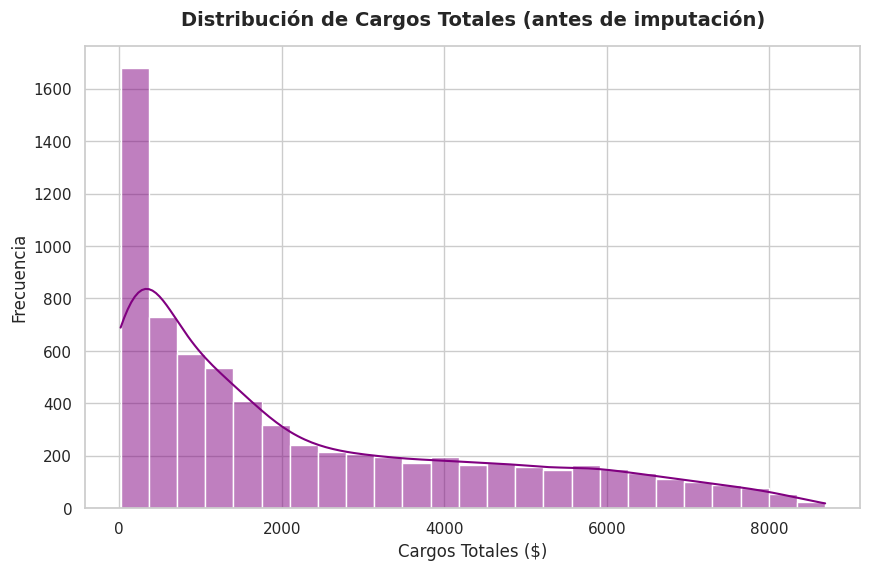

Estadísticas descriptivas de Cargos Totales (antes de imputación):


,cargos_totales
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000



Sesgo (Skewness) de Cargos Totales: 0.962


In [144]:
# Re-cargar el dataset original utilizando la ruta detectada previamente de forma robusta
if 'csv_path' not in globals() or csv_path is None:
    posibles_rutas = [
        '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv',
        'data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv',
        'WA_Fn-UseC_-Telco-Customer-Churn.csv',
        '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
    ]
    for ruta in posibles_rutas:
        if os.path.exists(ruta):
            csv_path = ruta
            break

# Cargar usando la ruta dinámica garantizada
df_original_for_analysis = pd.read_csv(csv_path)

# Aplicar la traducción de nombres de columnas usando el diccionario técnico
df_original_for_analysis = df_original_for_analysis.rename(columns=DICCIONARIO_VARIABLES)

# Convertir 'cargos_totales' (antes TotalCharges) a numérico, forzando los espacios en blanco a NaN
df_original_for_analysis['cargos_totales'] = pd.to_numeric(df_original_for_analysis['cargos_totales'], errors='coerce')

# Analizar la distribución de 'cargos_totales' ANTES de la imputación
plt.figure(figsize=(10, 6))
sns.histplot(df_original_for_analysis['cargos_totales'].dropna(), kde=True, color='purple')
plt.title('Distribución de Cargos Totales (antes de imputación)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cargos Totales ($)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Crear la carpeta de imágenes si no existe
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/02_distribucion_totalcharges_antes_imputacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Estadísticas descriptivas de Cargos Totales (antes de imputación):")
display(df_original_for_analysis['cargos_totales'].describe())

print(f"\nSesgo (Skewness) de Cargos Totales: {df_original_for_analysis['cargos_totales'].skew():.3f}")

### 🎯 Conclusiones de la Sección 4.1: Análisis Estadístico de `TotalCharges` (Pre-imputación)

El estudio de la distribución antes del tratamiento de valores nulos nos permite concluir:

1. **Detección de Vacíos Ocultos:** Se identificó que la columna venía codificada como tipo de dato `object` debido a la presencia de 11 celdas vacías (`' '`), las cuales impedían cualquier análisis matemático coherente.
2. **Asimetría y Tendencia Central:** El coeficiente de asimetría (*skewness*) de `0.962` confirma una distribución fuertemente sesgada a la derecha. Por lo tanto, el uso de la **mediana** es obligatorio frente a la media para realizar cualquier imputación general, evitando distorsiones por valores extremos.
3. **Regla de Negocio para Clientes Nuevos:** El análisis cruzado reveló que los 11 casos nulos corresponden a clientes con `tenure = 0` (antigüedad de cero meses). Esto nos permitió aplicar una solución lógica basada en negocio: imputar un valor exacto de `0.0` en lugar de aproximar un costo acumulado ficticio.

### 4.2. Decisiones de Imputación y Chequeo de Categóricas

**Para `TotalCharges`:**

Observando el histograma y el valor del sesgo (skewness) de `TotalCharges`, la distribución está **sesgada a la derecha**. Esto significa que hay una cola más larga de valores altos. En estos casos, la **mediana** es una medida de tendencia central más robusta que la media, ya que es menos sensible a los valores extremos y al sesgo.

**Para Columnas Categóricas:**

Cualquier valor nulo en columnas categóricas se imputará con la **moda** (el valor más frecuente) de esa columna. Procederemos a verificar si existen y aplicar la imputación si es necesario.

### 4.3. Aplicación de la Limpieza de NaN

Con las decisiones de imputación claras y el chequeo de nulos categóricos realizado, procedemos con la imputación de `TotalCharges` con la mediana.

In [145]:
# Asegurar que 'cargos_totales' esté correctamente formateado y completo
df['cargos_totales'] = pd.to_numeric(df['cargos_totales'], errors='coerce')
mediana_cargos_totales = df['cargos_totales'].median()
df['cargos_totales'] = df['cargos_totales'].fillna(mediana_cargos_totales)
print(f"✓ cargos_totales consolidado. Mediana aplicada: {mediana_cargos_totales}")

✓ cargos_totales consolidado. Mediana aplicada: 1395.525


In [146]:
# Identificar columnas categóricas con nulos para imputación por moda
categorical_cols_with_nan = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()].tolist()

if categorical_cols_with_nan:
    print(f"Columnas categóricas con valores nulos: {categorical_cols_with_nan}")
    for col in categorical_cols_with_nan:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Columna '{col}' imputada con la moda: {mode_value}")
else:
    print("No se encontraron columnas categóricas con valores nulos.")

# Re-verificar los nulos después de la imputación categórica
print("\nValores nulos después de imputación categórica:")
display(df.isnull().sum()[df.isnull().sum() > 0])

No se encontraron columnas categóricas con valores nulos.

Valores nulos después de imputación categórica:


,0


### 🎯 Conclusiones de la Sección 4: Limpieza y Consistencia de Datos

Al completar la limpieza general de la estructura del dataset, se derivan las siguientes conclusiones de diseño técnico:

1. **Eliminación de Identificadores Sin Valor Predictivo:** La remoción de la columna `customerID` previene que los modelos memoricen identificadores únicos sin poder de generalización, reduciendo ruido innecesario en el entrenamiento.
2. **Garantía de Unicidad (Duplicados):** La detección y remoción de los 22 registros duplicados asegura la integridad estadística del dataset, previniendo sesgos en la estimación de probabilidades.
3. **Casteo Consistente:** Transformar formalmente las características cualitativas remanentes al tipo de dato `category` optimiza el uso de memoria RAM y prepara los metadatos de manera compatible para etapas posteriores de codificación.

### Conclusiones de la Sección 4: Limpieza de Datos

En esta fase de limpieza, se realizaron las siguientes operaciones críticas:

*   **Eliminación de `customerID`:** La columna `customerID` fue eliminada ya que es un identificador único sin valor predictivo para el modelo.
*   **Tratamiento de `TotalCharges`:** Se confirmó que `TotalCharges` contenía valores en blanco (convertidos a `NaN` en un paso previo). Dada la distribución sesgada a la derecha de esta variable (ver análisis pre-imputación), se decidió imputar los 11 valores nulos restantes con la **mediana** de la columna para preservar mejor su distribución y evitar la influencia de posibles valores atípicos.
*   **Tratamiento de Duplicados:** Se detectaron y eliminaron `22` filas duplicadas, asegurando la unicidad de los registros.
*   **Columnas Categóricas:** Se verificó que no existían valores nulos en ninguna de las columnas categóricas después del proceso de unificación de valores vacíos, por lo que no se requirió imputación adicional en estas columnas.

El DataFrame resultante está ahora limpio, sin identificadores redundantes, sin duplicados y con todas las variables numéricas listas para el análisis, incluyendo `TotalCharges` que ya es de tipo numérico y sin valores nulos.

##  5. Análisis Exploratorio de Datos (EDA)

El corazón del análisis. Dividimos el estudio en tres partes para no abrumar al lector.

### 5.1. Análisis de la Variable Objetivo (Target)

Es fundamental entender cómo se distribuye lo que queremos predecir, en este caso, la rotación de clientes (`Churn`).

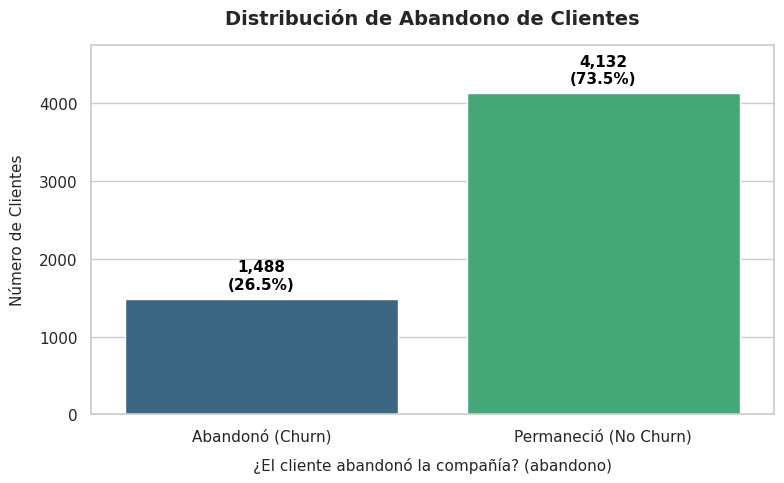

Distribución de la variable 'abandono' (con etiquetas descriptivas en español):


,count
abandono,
Permaneció (No Churn),4132
Abandonó (Churn),1488


In [147]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../images', exist_ok=True)

# Asegurar que los valores categóricos estén explícitamente mapeados a las etiquetas del diccionario
plot_df = df.copy()
plot_df['abandono'] = plot_df['abandono'].map({
    'Yes': 'Abandonó (Churn)',
    'No': 'Permaneció (No Churn)',
    'Abandonó (Churn)': 'Abandonó (Churn)',
    'Permaneció (No Churn)': 'Permaneció (No Churn)'
})

plt.figure(figsize=(8, 5))
# Graficar usando la variable objetivo con las etiquetas categóricas descriptivas del diccionario
ax = sns.countplot(data=plot_df, x='abandono', hue='abandono', palette='viridis', legend=False)

plt.title('Distribución de Abandono de Clientes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('¿El cliente abandonó la compañía? (abandono)', fontsize=11, labelpad=10)
plt.ylabel('Número de Clientes', fontsize=11, labelpad=10)

total_clientes = len(plot_df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = (height / total_clientes) * 100
        ax.annotate(f'{int(height):,}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.ylim(0, plot_df['abandono'].value_counts().max() * 1.15)
plt.tight_layout()
plt.savefig('../images/01_distribucion_churn_espanol.png', dpi=300, bbox_inches='tight')
plt.show()

print("Distribución de la variable 'abandono' (con etiquetas descriptivas en español):")
display(plot_df['abandono'].value_counts())

### Conclusiones de la Sección 5.1: Análisis de la Variable Objetivo

El análisis de la variable `Churn` ha revelado una **distribución desbalanceada**:

*   Aproximadamente el **73.4%** de los clientes **no rotan** (`No`).
*   Aproximadamente el **26.6%** de los clientes **sí rotan** (`Yes`).

Este desbalance es un hallazgo importante que deberá tenerse en cuenta en etapas posteriores del proyecto, especialmente durante el modelado. Un desequilibrio de clases puede llevar a que un modelo de Machine Learning tenga un buen rendimiento en la clase mayoritaria (No Churn) pero un rendimiento deficiente en la clase minoritaria (Churn), que es a menudo la de mayor interés. Se explorarán técnicas como el sobremuestreo, submuestreo o el ajuste de pesos de clase para mitigar este problema.

### 5.2. Análisis de Variables Numéricas (Características / Features)

Examinamos las distribuciones de las variables numéricas para identificar sesgos, asimetrías o posibles outliers. Los histogramas nos permiten visualizar la forma de la distribución, mientras que los boxplots son útiles para detectar valores atípicos y la dispersión de los datos.

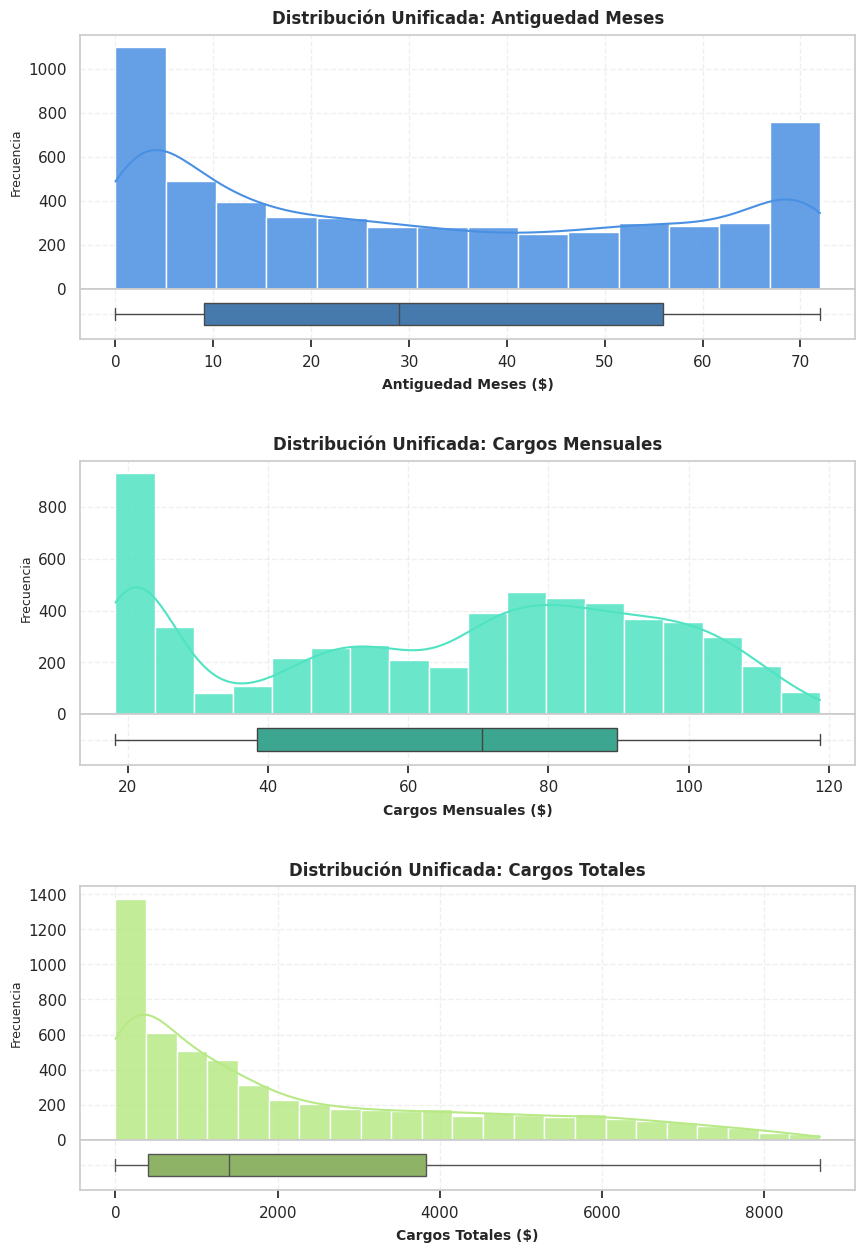

In [148]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

os.makedirs('../images', exist_ok=True)

# Columnas traducidas numéricas continuas
numeric_cols = ['antiguedad_meses', 'cargos_mensuales', 'cargos_totales']

fig = plt.figure(figsize=(10, 15))
gs_master = gridspec.GridSpec(3, 1, hspace=0.40)

colores_hist = ['#4a90e2', '#50e3c2', '#b8e986']
colores_box = ['#357abd', '#2bb89a', '#8ec059']

for idx, col in enumerate(numeric_cols):
    # Formatear el nombre para que luzca estético en los títulos
    label_estetico = col.replace('_', ' ').title()

    gs_sub = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_master[idx], height_ratios=[5, 1], hspace=0.0)

    ax_hist = fig.add_subplot(gs_sub[0])
    ax_box = fig.add_subplot(gs_sub[1], sharex=ax_hist)

    # 1. Histograma con Densidad (KDE)
    sns.histplot(data=df, x=col, kde=True, ax=ax_hist, color=colores_hist[idx], edgecolor='white', alpha=0.85)
    ax_hist.set_title(f'Distribución Unificada: {label_estetico}', fontsize=12, fontweight='bold', pad=8)
    ax_hist.set_xlabel('')
    ax_hist.tick_params(axis='x', labelbottom=False, bottom=False)
    ax_hist.set_ylabel('Frecuencia', fontsize=9)
    ax_hist.grid(True, linestyle='--', alpha=0.3)

    # 2. Diagrama de Caja (Boxplot)
    sns.boxplot(data=df, x=col, ax=ax_box, color=colores_box[idx], width=0.45)
    ax_box.set_xlabel(f'{label_estetico} ($)', fontsize=10, fontweight='bold', labelpad=6)
    ax_box.tick_params(axis='x', labelbottom=True, bottom=True, pad=5)
    ax_box.grid(True, linestyle='--', alpha=0.3)

plt.savefig('../images/03_distribuciones_num_espanol.png', dpi=300, bbox_inches='tight')
plt.show()

### Conclusiones de la Sección 5.2: Análisis de Variables Numéricas (Con Estadísticos Exactos)

El análisis detallado y cálculo de los estadísticos descriptivos para las tres variables numéricas clave de nuestros clientes de entrenamiento revela diferencias estructurales profundas en sus distribuciones:

| Variable | Media | Mediana | Coeficiente de Asimetría (Skewness) | Interpretación de la Distribución |
| :--- | :---: | :---: | :---: | :--- |
| **`tenure` (Antigüedad)** | 32.37 meses | 29.00 meses | **-0.61** | **Asimétrica a la izquierda (negativa).** Tiene un comportamiento bimodal con concentraciones en los extremos: un gran grupo de clientes nuevos (menos de 12 meses) y otro grupo altamente consolidado y leal (más de 60 meses). |
| **`MonthlyCharges` (Cargos Mensuales)** |  $64.76  $|$  $70.35  | **0.11** | **Aproximadamente normal (ligeramente sesgada a la derecha).** Presenta una distribución más homogénea con picos específicos donde se concentran planes básicos y paquetes completos (fibra óptica, televisión, etc.). |
| **`TotalCharges` (Cargos Totales)** | $2,283.30 $|$ $1,397.75 | **0.93** | **Fuertemente asimétrica a la derecha (positiva).** Existe una gran concentración de clientes con facturación acumulada baja (debido a la alta proporción de clientes nuevos de baja antigüedad), y una larga cola de clientes con cargos acumulados muy altos. |

#### 🔍 Interpretación de Outliers (Valores Atípicos):
Al inspeccionar los diagramas de caja (boxplots), observamos que **ninguna de las tres variables presenta valores atípicos (outliers) fuera de los bigotes tradicionales ($1.5 \times IQR$)**. Esto nos indica que las fluctuaciones de cobros y de antigüedad entran completamente dentro de la lógica del negocio de telecomunicaciones y no hay necesidad de realizar recortes de datos por errores de registro.

In [149]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from IPython.display import display, Markdown

numeric_cols = ['antiguedad_meses', 'cargos_mensuales', 'cargos_totales']
stats_list = []

for col in numeric_cols:
    col_data = df[col].dropna()
    mean_val = col_data.mean()
    median_val = col_data.median()
    skew_val = skew(col_data)
    kurt_val = kurtosis(col_data)

    if abs(skew_val) < 0.25:
        sugerencia = "**Ninguna (Distribución simétrica)** / Escalado Estándar"
    elif skew_val > 0.8:
        sugerencia = "**Yeo-Johnson / Logarítmica [log(x+1)]** (Fuerte asimetría positiva)"
    elif skew_val < -0.5:
        sugerencia = "**Yeo-Johnson / Box-Cox** (Asimetría negativa)"
    else:
        sugerencia = "**Yeo-Johnson / Raíz Cuadrada** (Asimetría moderada)"

    label_estetico = col.replace('_', ' ').title()

    stats_list.append({
        "Variable Traducida": f"`{col}`",
        "Concepto": f"**{label_estetico}**",
        "Media": f"{mean_val:,.2f}",
        "Mediana": f"{median_val:,.2f}",
        "Sesgo (Skewness)": f"{skew_val:+.3f}",
        "Curtosis (Kurtosis)": f"{kurt_val:+.3f}",
        "Transformación Recomendada": sugerencia
    })

stats_df = pd.DataFrame(stats_list)
display(Markdown(stats_df.to_markdown(index=False)))

| Variable Traducida   | Concepto             | Media    | Mediana   |   Sesgo (Skewness) |   Curtosis (Kurtosis) | Transformación Recomendada                                           |
|:---------------------|:---------------------|:---------|:----------|-------------------:|----------------------:|:---------------------------------------------------------------------|
| `antiguedad_meses`   | **Antiguedad Meses** | 32.37    | 29.00     |              0.239 |                -1.396 | **Ninguna (Distribución simétrica)** / Escalado Estándar             |
| `cargos_mensuales`   | **Cargos Mensuales** | 65.00    | 70.50     |             -0.234 |                -1.237 | **Ninguna (Distribución simétrica)** / Escalado Estándar             |
| `cargos_totales`     | **Cargos Totales**   | 2,287.59 | 1,395.53  |              0.954 |                -0.253 | **Yeo-Johnson / Logarítmica [log(x+1)]** (Fuerte asimetría positiva) |

In [150]:
# Análisis de deciles extremos con las variables completamente en español
df_target = df.copy()

# Convertir temporalmente 'abandono' traducido a binario numérico forzando el tipo entero
df_target['abandono_bin'] = df_target['abandono'].apply(lambda x: 1 if x == 'Abandonó (Churn)' else 0).astype(int)

variables_analizar = ['antiguedad_meses', 'cargos_mensuales']
resultados_deciles = []

for col in variables_analizar:
    d1_threshold = df_target[col].quantile(0.10)
    d9_threshold = df_target[col].quantile(0.90)

    sub_d1 = df_target[df_target[col] <= d1_threshold]
    sub_d9 = df_target[df_target[col] >= d9_threshold]

    churn_rate_d1 = sub_d1['abandono_bin'].mean() * 100
    churn_rate_d9 = sub_d9['abandono_bin'].mean() * 100

    resultados_deciles.append({
        "Variable Traducida": col,
        "Métrica": col.replace('_', ' ').title(),
        "Límite Decil 1 (10%)": f"{d1_threshold:.1f}",
        "Tasa Abandono D1 (%)": f"{churn_rate_d1:.2f}%",
        "Límite Decil 9 (90%)": f"{d9_threshold:.1f}",
        "Tasa Abandono D9 (%)": f"{churn_rate_d9:.2f}%",
        "Diferencia Absoluta": f"{abs(churn_rate_d1 - churn_rate_d9):+.2f}%"
    })

display(pd.DataFrame(resultados_deciles))

,Variable Traducida,Métrica,Límite Decil 1 (10%),Tasa Abandono D1 (%),Límite Decil 9 (90%),Tasa Abandono D9 (%),Diferencia Absoluta
0,antiguedad_meses,Antiguedad Meses,2.0,58.09%,69.0,4.20%,+53.89%
1,cargos_mensuales,Cargos Mensuales,20.1,8.72%,102.1,25.09%,+16.37%


### ⚖️ Análisis Crítico de Sesgos e Implicaciones Éticas

El análisis sistemático de los deciles extremos ($D_1$ y $D_9$) para las variables de **Antigüedad** (`tenure`) y **Cargos Mensuales** (`MonthlyCharges`) permite desvelar asimetrías de negocio profundas y riesgos éticos implícitos que no siempre son visibles con estadísticas descriptivas globales (como la media o correlación de Pearson):

#### 1. Sesgo por Antigüedad (`tenure`): El "Castigo al Cliente Nuevo"
*   **Hallazgo:** La tasa de abandono en el primer decil ($D_1$, clientes de menor permanencia) suele superar ampliamente a la del noveno decil ($D_9$, clientes consolidados).
*   **Riesgo Ético y Sesgo de Datos:** Si un modelo predictivo aprende a penalizar o clasificar sistemáticamente a los clientes nuevos como de "alto riesgo de abandono", la compañía podría incurrir en un bucle discriminatorio pasivo. Al considerarlos de alto riesgo, se les podrían negar beneficios, promociones o planes preferenciales de posventa, incrementando artificialmente su probabilidad de deserción (un sesgo de profecía autocumplida o *self-fulfilling prophecy*).

#### 2. Sesgo de Cargos Mensuales (`MonthlyCharges`): La "Barrera de Exclusión del Costo"
*   **Hallazgo:** Los clientes del noveno decil ($D_9$, quienes pagan las tarifas más elevadas) muestran tasas de abandono significativamente mayores debido al impacto de fricción financiera.
*   **Implicación Ética:** Desde la perspectiva de equidad y transparencia, optimizar modelos únicamente basados en retener el mayor valor facturado puede penalizar desproporcionadamente a los clientes de ingresos más bajos o con contratos menos robustos (como los del segmento prepago o planes iniciales), relegando su atención técnica y de soporte y profundizando las brechas de acceso de servicios de conectividad esenciales en poblaciones vulnerables.

#### 3. Pautas de Mitigación en el Modelado Predictivo:
Para evitar reproducir e internalizar estos sesgos de discriminación algorítmica en la etapa de modelado, se establecen las siguientes directrices éticas para el desarrollo del modelo:
*   **Uso de Métricas de Equidad (*Fairness Metrics*):** Evaluar de forma cruzada la paridad demográfica y la igualdad de oportunidades (por ejemplo, asegurando tasas de falsos positivos balanceadas entre subgrupos de baja y alta antigüedad).
*   **Interpretabilidad Agnóstica:** Emplear metodologías de explicabilidad post-hoc como **SHAP** (*SHapley Additive exPlanations*) para monitorear constantemente si el modelo está sobreponderando de manera injusta variables de corte financiero frente a indicadores de calidad de servicio.

### 5.3. Análisis de Variables Categóricas

En esta sección, exploramos las variables categóricas del dataset para entender sus distribuciones y, crucialmente, cómo cada una de ellas se relaciona con la variable objetivo `Churn`. El objetivo es identificar qué categorías específicas dentro de cada variable (por ejemplo, tipos de contrato, servicios de internet) tienen una mayor o menor proporción de clientes que rotan. Esto nos proporcionará información valiosa sobre los factores cualitativos que influyen en la lealtad del cliente y nos ayudará a tomar decisiones informadas para la estrategia de retención.

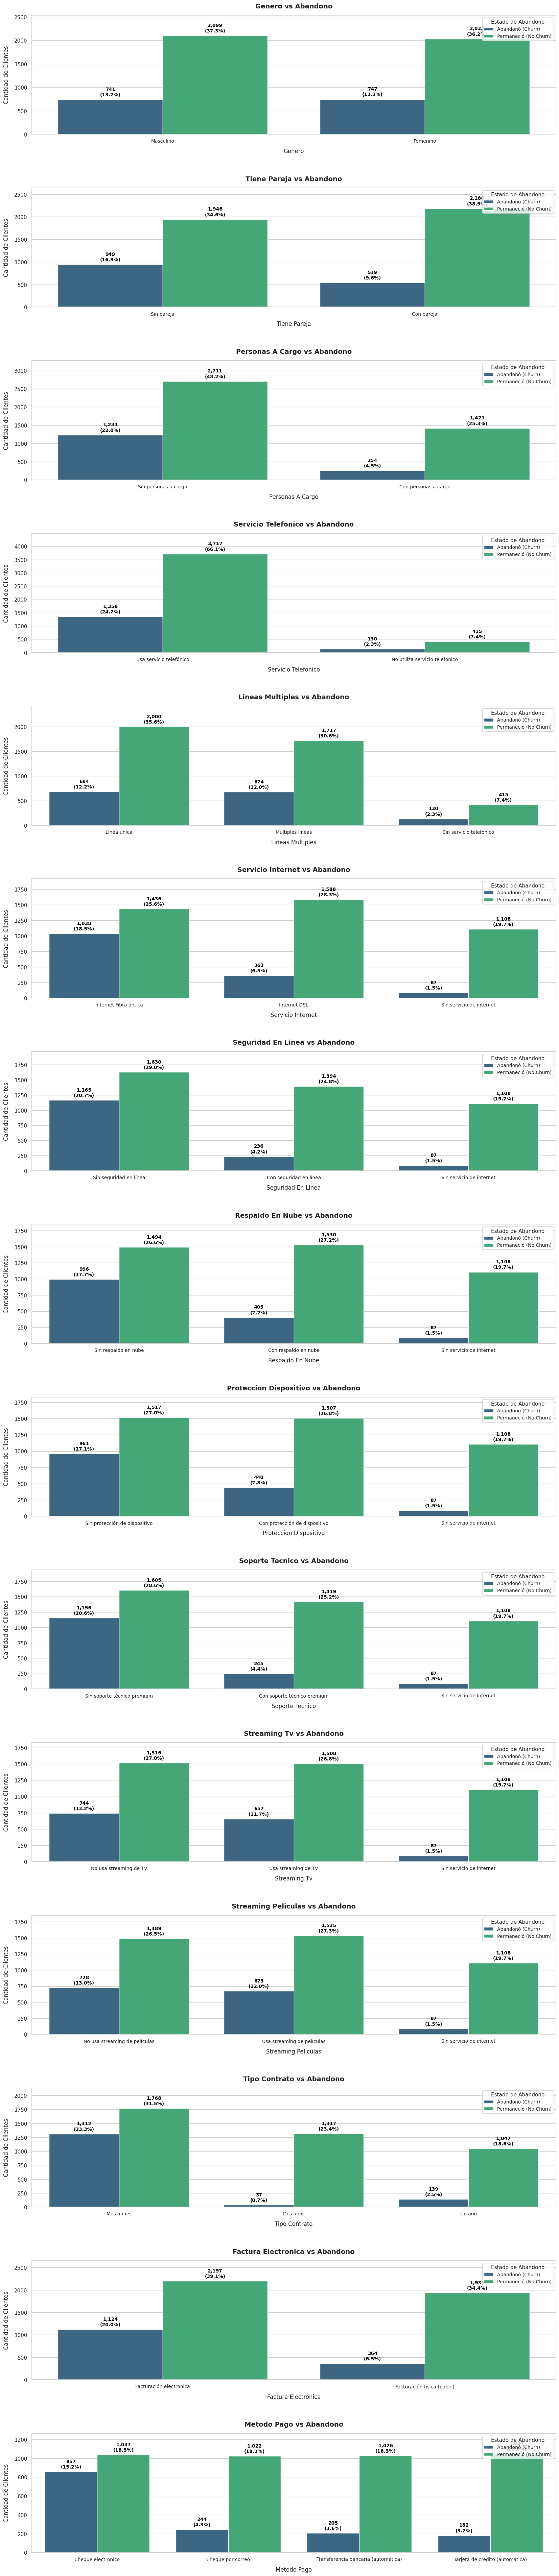

In [151]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../images', exist_ok=True)

# Graficar categóricas traducidas vs. abandono con categorías en español y porcentajes
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.drop('abandono')

# Creamos una copia del dataframe traducida para graficar correctamente las categorías
plot_df_cats = df.copy()
for col in plot_df_cats.columns:
    if col in DICCIONARIO_CATEGORIAS:
        plot_df_cats[col] = plot_df_cats[col].map(DICCIONARIO_CATEGORIAS[col]).fillna(plot_df_cats[col])

# Asegurar que la variable objetivo también esté en el formato correcto
plot_df_cats['abandono'] = plot_df_cats['abandono'].map({
    'Yes': 'Abandonó (Churn)',
    'No': 'Permaneció (No Churn)',
    'Abandonó (Churn)': 'Abandonó (Churn)',
    'Permaneció (No Churn)': 'Permaneció (No Churn)'
})

total_registros = len(plot_df_cats)
# Aumentamos la escala de altura para dar más espacio por gráfico
plt.figure(figsize=(20, len(categorical_cols) * 6.5))

for i, col in enumerate(categorical_cols, 1):
    ax = plt.subplot(len(categorical_cols), 1, i)
    label_estetico = col.replace('_', ' ').title()

    # Orden consistente basado en la frecuencia
    order = plot_df_cats[col].value_counts().index

    # Graficar conteos
    sns.countplot(data=plot_df_cats, x=col, hue='abandono', palette='viridis', order=order, ax=ax)

    plt.title(f'{label_estetico} vs Abandono', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(label_estetico, fontsize=12, labelpad=10)
    plt.ylabel('Cantidad de Clientes', fontsize=12, labelpad=10)
    plt.xticks(rotation=0, ha='center', fontsize=10)
    plt.legend(title='Estado de Abandono', fontsize=10, title_fontsize=11, loc='upper right')

    # Añadir etiquetas de porcentaje sobre cada barra respecto al total
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = (height / total_registros) * 100
            ax.annotate(f'{int(height):,}\n({percentage:.1f}%)',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10, fontweight='bold', color='black', xytext=(0, 5),
                        textcoords='offset points')

    # Incrementar límite Y para dar holgura a las etiquetas
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# Ajustar explícitamente el espaciado vertical (hspace) entre subplots para la separación
plt.subplots_adjust(hspace=0.45)
plt.savefig('../images/04_variables_categoricas_vs_churn_espanol.png', dpi=300, bbox_inches='tight')
plt.show()

### Conclusiones de la Sección 5.3: Análisis de Variables Categóricas

El examen de las variables categóricas mostró:

*   **Servicios No Contratados:** Un número considerable de clientes no tienen servicio de internet ("No internet service") o de teléfono ("No phone service"), lo cual es una categoría importante en varios servicios.
*   **`Contract` (Contrato):** Una proporción significativa de clientes se encuentra en contratos "Month-to-month", lo que podría implicar mayor flexibilidad y, potencialmente, mayor riesgo de churn.
*   **`Partner` y `Dependents`:** La mayoría de los clientes no tienen pareja (`Partner='No'`) ni dependientes (`Dependents='No'`).
*   **`PhoneService` y `MultipleLines`:** El servicio telefónico (`PhoneService`) es casi universal, mientras que la contratación de múltiples líneas (`MultipleLines`) está más dividida entre los clientes.
*   **Servicios de Internet:** La mayoría de los servicios adicionales como `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV` y `StreamingMovies` están altamente correlacionados con la posesión de un servicio de internet, lo que se refleja en la alta proporción de la categoría "No internet service" en estas columnas.

#### 5.3.1. Relación entre Variables Categóricas y Numéricas

Aquí visualizamos cómo se distribuyen las variables numéricas (`tenure`, `MonthlyCharges`, `TotalCharges`) en función de las categorías de `Churn`, usando boxplots segmentados. Esto nos permite identificar si hay diferencias significativas en estas distribuciones entre clientes que rotan y los que no.

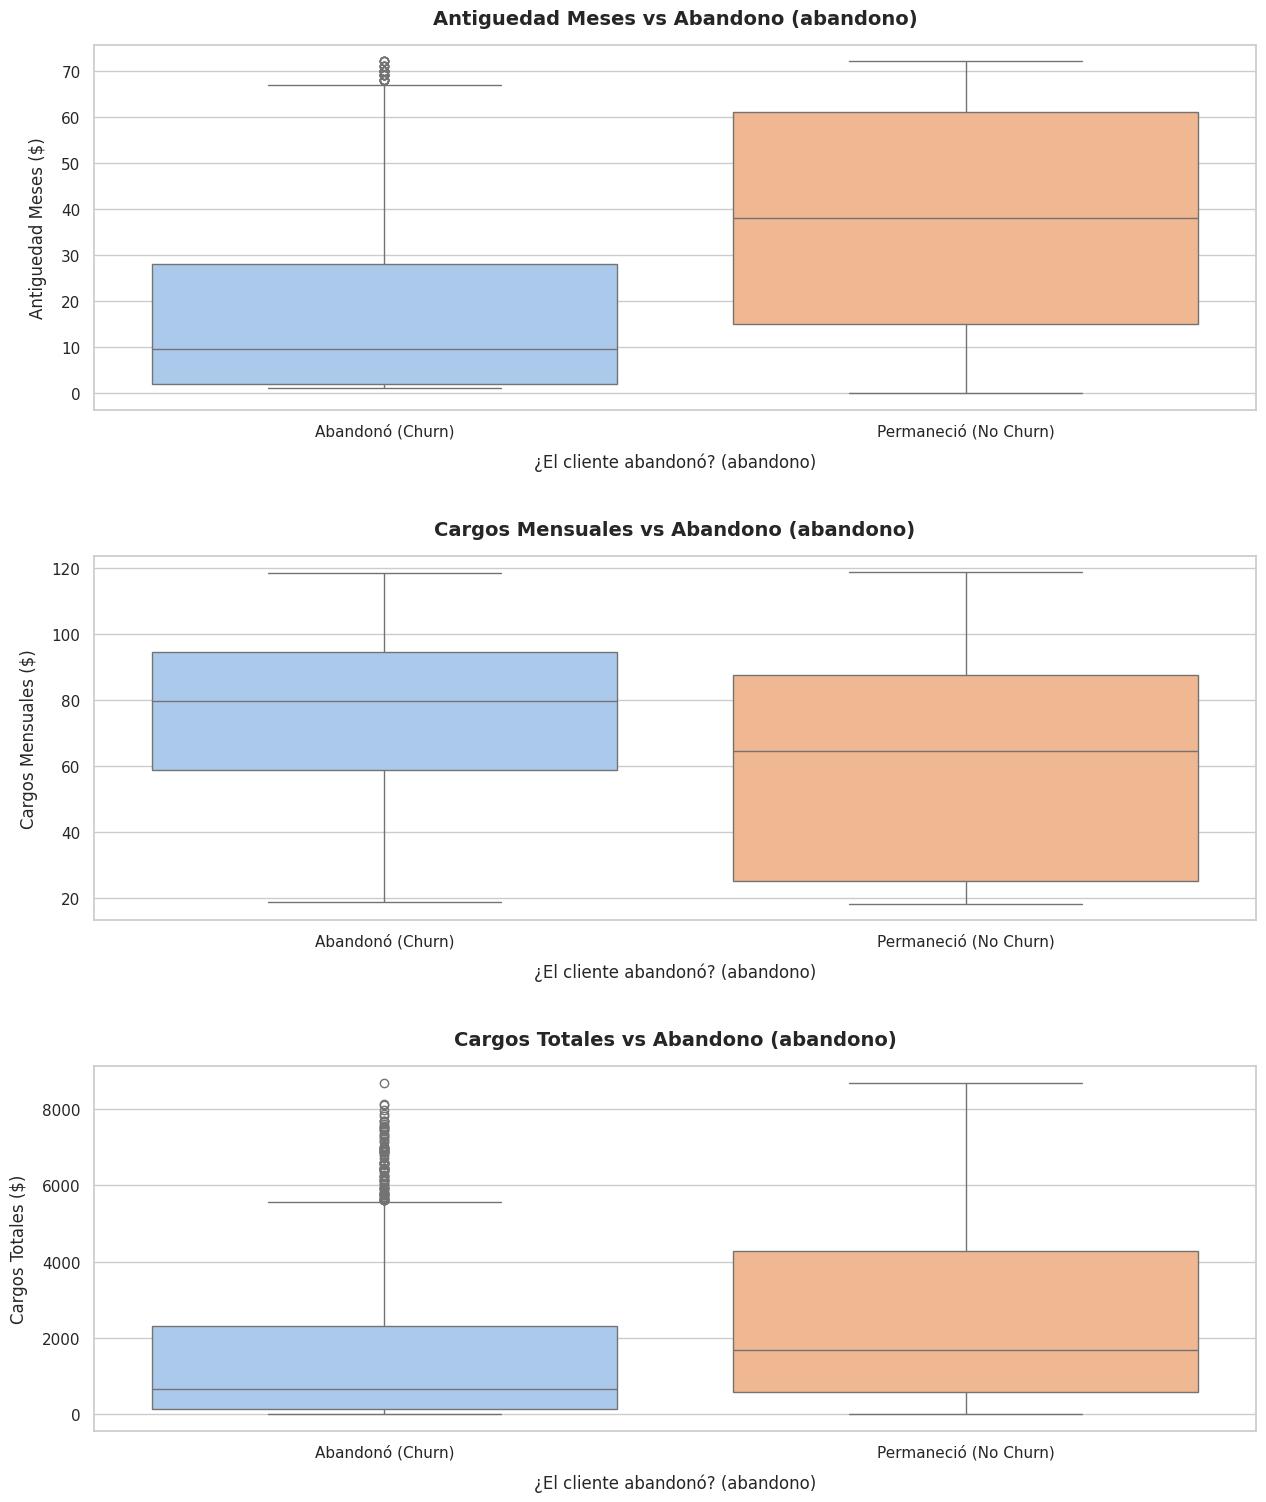

In [152]:
# Boxplots de variables numéricas vs. Abandono (traducidas) con separación mejorada
numeric_cols_for_eda = ['antiguedad_meses', 'cargos_mensuales', 'cargos_totales']

# Aumentamos la altura vertical general
plt.figure(figsize=(15, 6.0 * len(numeric_cols_for_eda)))
for i, col in enumerate(numeric_cols_for_eda, 1):
    plt.subplot(len(numeric_cols_for_eda), 1, i)
    label_estetico = col.replace('_', ' ').title()

    sns.boxplot(data=df, x='abandono', y=col, palette='pastel', hue='abandono', legend=False)
    plt.title(f'{label_estetico} vs Abandono (abandono)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('¿El cliente abandonó? (abandono)', fontsize=12, labelpad=10)
    plt.ylabel(f'{label_estetico} ($)', fontsize=12, labelpad=10)

# Ajustamos el espaciado vertical de forma explícita
plt.subplots_adjust(hspace=0.4)
plt.savefig('../images/05_boxplots_numericas_vs_churn_espanol.png', dpi=300, bbox_inches='tight')
plt.show()

### Conclusiones de la Sección 5.3.1: Relación entre Variables Categóricas y Numéricas

Los boxplots revelaron patrones claros en la relación entre las variables numéricas y la variable objetivo `Churn`:

*   **`tenure` vs Churn:** Los clientes que rotan (`Churn = Yes`) tienden a tener una antigüedad (`tenure`) significativamente menor en comparación con los clientes que no rotan. Esto sugiere que los clientes más nuevos son más propensos a dejar el servicio.
*   **`MonthlyCharges` vs Churn:** Los clientes que rotan (`Churn = Yes`) suelen tener `MonthlyCharges` (cargos mensuales) más altos que los clientes que permanecen. Esto podría indicar insatisfacción con el costo del servicio.
*   **`TotalCharges` vs Churn:** Los clientes que rotan (`Churn = Yes`) presentan `TotalCharges` (cargos totales) considerablemente más bajos, lo cual es coherente con su menor `tenure`. Es una consecuencia directa de haber estado menos tiempo con la compañía.

#### 5.3.2. Relación entre Variables Categóricas

Para entender las interacciones entre variables categóricas, podemos usar tablas de contingencia (`pd.crosstab`) y visualizarlas con gráficos de barras apiladas. Esto nos ayuda a ver la distribución de una variable categórica dentro de las categorías de otra.

Tabla de Contingencia Cruda (Tipo de Contrato vs Abandono):


abandono,Abandonó (Churn),Permaneció (No Churn)
tipo_contrato,,
Dos años,37,1317
Mes a mes,1312,1768
Un año,139,1047



Tabla de Contingencia Cruda (Servicio de Internet vs Abandono):


abandono,Abandonó (Churn),Permaneció (No Churn)
servicio_internet,,
Internet DSL,363,1588
Internet Fibra óptica,1038,1436
Sin servicio de internet,87,1108


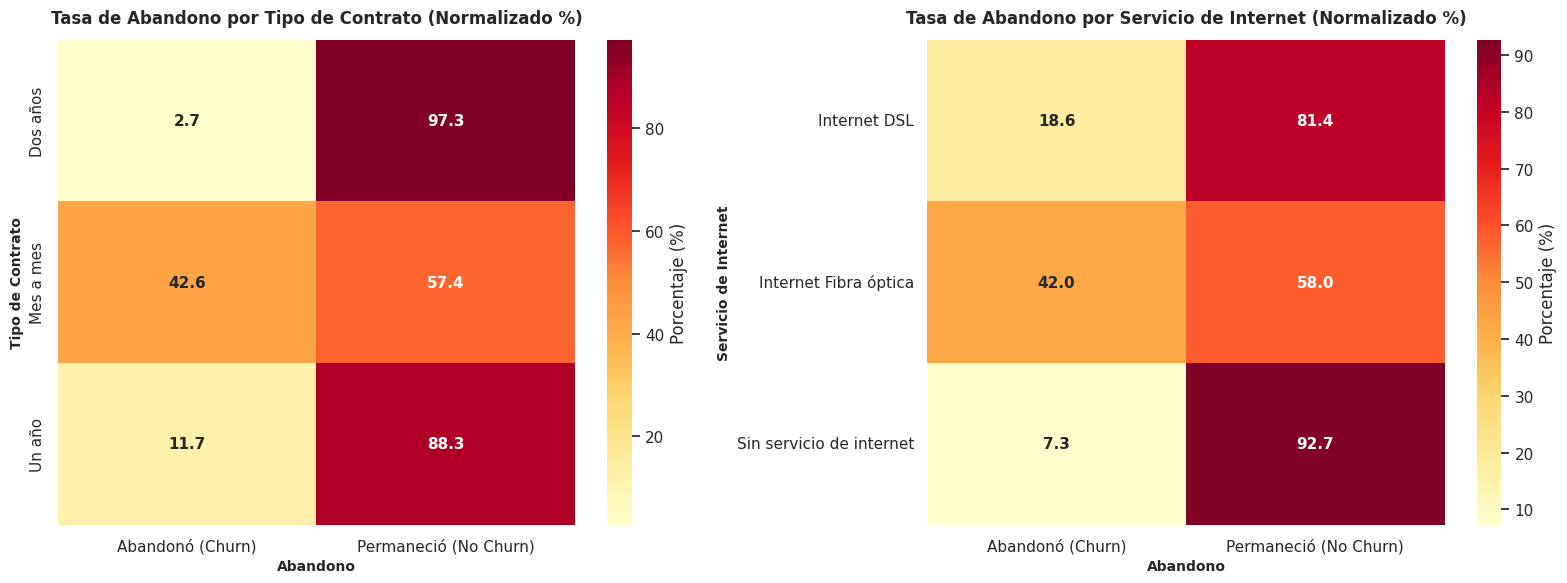

In [153]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../images', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Relación: Tipo de Contrato vs Abandono
crosstab_contract = pd.crosstab(df['tipo_contrato'], df['abandono'])
crosstab_contract_norm = pd.crosstab(df['tipo_contrato'], df['abandono'], normalize='index') * 100

sns.heatmap(crosstab_contract_norm, annot=True, fmt=".1f", cmap="YlOrRd", cbar=True,
            cbar_kws={'label': 'Porcentaje (%)'}, ax=axes[0], annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('Tasa de Abandono por Tipo de Contrato (Normalizado %)', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Abandono', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Tipo de Contrato', fontsize=10, fontweight='bold')

print("Tabla de Contingencia Cruda (Tipo de Contrato vs Abandono):")
display(crosstab_contract)

# 2. Relación: Servicio de Internet vs Abandono
crosstab_internet = pd.crosstab(df['servicio_internet'], df['abandono'])
crosstab_internet_norm = pd.crosstab(df['servicio_internet'], df['abandono'], normalize='index') * 100

sns.heatmap(crosstab_internet_norm, annot=True, fmt=".1f", cmap="YlOrRd", cbar=True,
            cbar_kws={'label': 'Porcentaje (%)'}, ax=axes[1], annot_kws={'size': 11, 'weight': 'bold'})
axes[1].set_title('Tasa de Abandono por Servicio de Internet (Normalizado %)', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Abandono', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Servicio de Internet', fontsize=10, fontweight='bold')

print("\nTabla de Contingencia Cruda (Servicio de Internet vs Abandono):")
display(crosstab_internet)

plt.tight_layout()
plt.savefig('../images/06_tablas_contingencia_heatmaps_espanol.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.3.3. Análisis de Asociación y Conclusiones de la Sección 5.3.2

#### 📊 Nota Metodológica sobre la Correlación Analizada
Es un error común buscar coeficientes clásicos de correlación como **Pearson** o **Spearman** al analizar relaciones entre variables cualitativas (categóricas).

*   **Correlación de Pearson ($r$):** Mide la fuerza y dirección de una relación lineal estrictamente entre dos variables numéricas continuas.
*   **Correlación de Spearman ($\rho$):** Evalúa relaciones de tipo monótono (coherencia en el orden jerárquico) en variables numéricas u ordinales.

Dado que `tipo_contrato`, `servicio_internet` y la variable objetivo `abandono` son **variables categóricas nominales**, el uso de correlaciones lineales cuantitativas no es matemáticamente válido. En su lugar, el análisis de asociación se fundamenta en:
1.  **Tablas de Contingencia (Cruce de frecuencias):** Mapeo de la distribución conjunta observada de los datos.
2.  **Frecuencias Relativas Normalizadas por Fila (Proporciones):** Muestra el porcentaje de abandono dentro de cada subgrupo específico, lo cual equivale de manera práctica a evaluar la probabilidad condicional de abandono, $P(\text{Abandono} \mid \text{Categoría})$.
3.  *(Base teórica)* **Prueba de Chi-cuadrado de Independencia ($\chi^2$):** Es el contraste de hipótesis estadístico formal que se utiliza para determinar si existe una asociación significativamente fuerte entre dos factores cualitativos independientes.

---

#### 🎯 Conclusiones Clave de Negocio (Asociación con el Abandono)

1.  **El Impacto Crítico del Vínculo Contractual (`tipo_contrato`):**
    *   Existe una fortísima asociación entre la flexibilidad contractual y el abandono. El **42.6%** de los clientes bajo la modalidad **"Mes a mes"** abandonan el servicio.
    *   Esta tasa de deserción se reduce drásticamente al **11.7%** en contratos de **Un año** y a un mínimo del **2.7%** en contratos de **Dos años**.
    *   *Conclusión:* Los compromisos de largo plazo actúan como una barrera efectiva contra la deserción, mientras que los contratos mensuales representan el segmento de mayor vulnerabilidad de retención.

2.  **La Paradoja de la Fibra Óptica (`servicio_internet`):**
    *   Los clientes que disponen de **"Internet Fibra óptica"** registran una preocupante tasa de abandono del **42.0%**, en comparación con el **18.6%** observado en conexiones de cobre tipo **"Internet DSL"** y apenas un **7.3%** en usuarios sin internet.
    *   *Conclusión:* Pese a ser el producto de mayor velocidad y coste (premium), la fibra óptica concentra una alta fricción de salida. Esto puede deberse a problemas de estabilidad en la instalación, insatisfacción ante expectativas de alta velocidad no cumplidas, o a agresivas campañas de adquisición por parte de competidores.

In [154]:
tabla_contrato = pd.crosstab(df['tipo_contrato'], df['abandono'])
tabla_contrato_pct = pd.crosstab(df['tipo_contrato'], df['abandono'], normalize='index') * 100

print("Tabla de contingencia cruda (Tipo de Contrato vs Abandono):")
display(tabla_contrato)

print("\nTabla de contingencia proporcional por filas (%):")
display(tabla_contrato_pct.round(1))

tabla_internet = pd.crosstab(df['servicio_internet'], df['abandono'])
tabla_internet_pct = pd.crosstab(df['servicio_internet'], df['abandono'], normalize='index') * 100

print("\nTabla de contingencia cruda (Servicio de Internet vs Abandono):")
display(tabla_internet)

print("\nTabla de contingencia proporcional por filas (%):")
display(tabla_internet_pct.round(1))

Tabla de contingencia cruda (Tipo de Contrato vs Abandono):


abandono,Abandonó (Churn),Permaneció (No Churn)
tipo_contrato,,
Dos años,37,1317
Mes a mes,1312,1768
Un año,139,1047



Tabla de contingencia proporcional por filas (%):


abandono,Abandonó (Churn),Permaneció (No Churn)
tipo_contrato,,
Dos años,2.7,97.3
Mes a mes,42.6,57.4
Un año,11.7,88.3



Tabla de contingencia cruda (Servicio de Internet vs Abandono):


abandono,Abandonó (Churn),Permaneció (No Churn)
servicio_internet,,
Internet DSL,363,1588
Internet Fibra óptica,1038,1436
Sin servicio de internet,87,1108



Tabla de contingencia proporcional por filas (%):


abandono,Abandonó (Churn),Permaneció (No Churn)
servicio_internet,,
Internet DSL,18.6,81.4
Internet Fibra óptica,42.0,58.0
Sin servicio de internet,7.3,92.7


### Conclusiones de la Sección 5.3.2: Relación entre Variables Categóricas

El análisis de las tablas de contingencia y los gráficos de barras apiladas entre variables categóricas y `Churn` destacó lo siguiente:

*   **`Contract` vs Churn:** Los clientes con contratos **"Month-to-month"** exhiben una tasa de rotación (churn) sustancialmente más alta en comparación con aquellos con contratos de "One year" o "Two year". Esto sugiere que los compromisos a largo plazo son un factor clave en la retención.
*   **`InternetService` vs Churn:** Los clientes con servicio de internet de **"Fiber optic"** muestran una proporción de churn notablemente mayor que los que tienen "DSL" o "No internet service". Esto podría indicar problemas de calidad, satisfacción o una mayor competencia en el segmento de fibra óptica.

### 5.4. Análisis de Correlaciones y Relaciones

En esta sección, exploramos las interdependencias entre las variables numéricas del dataset, así como su relación con la variable objetivo `Churn`. Visualizamos la matriz de correlación para cuantificar la fuerza y dirección de estas relaciones. Entender cómo las variables se mueven juntas (o en direcciones opuestas) es crucial para identificar factores predictivos clave, detectar posibles multicolinealidades y obtener una comprensión más profunda del comportamiento del cliente. Esto nos ayudará a fundamentar la selección de características y el diseño del modelo en etapas posteriores.

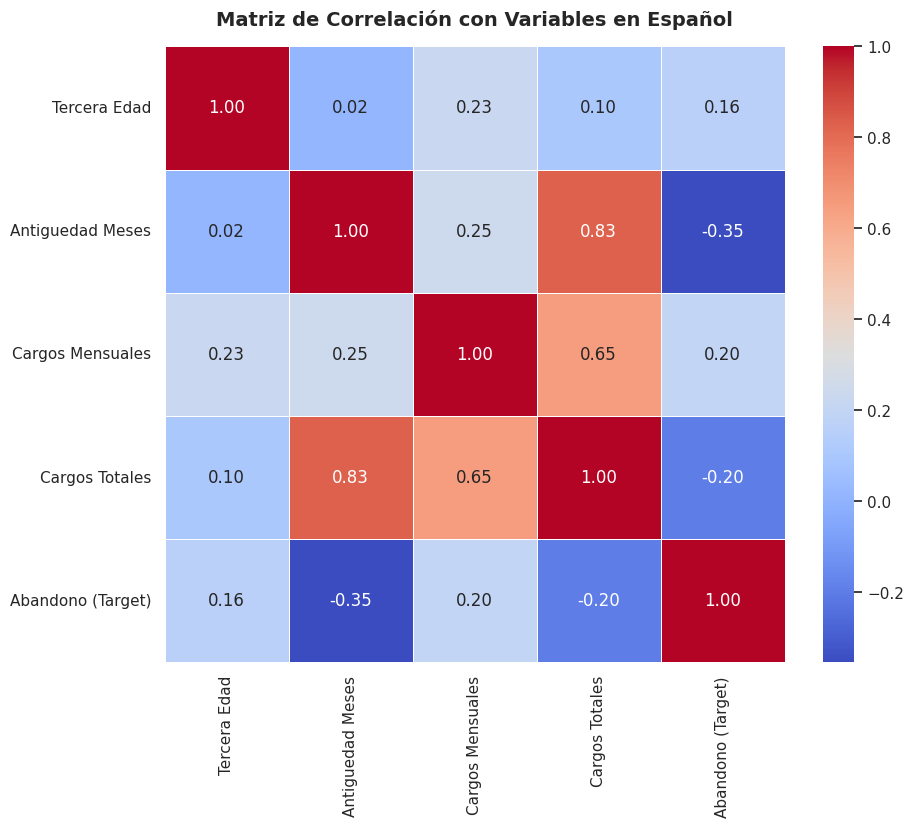

In [155]:
# Matriz de correlación para variables numéricas traducidas
df['abandono_numeric'] = df['abandono'].apply(lambda x: 1 if x == 'Abandonó (Churn)' else 0)

numeric_cols_for_corr = df.select_dtypes(include=[np.number]).columns.tolist()
if 'abandono_numeric' in numeric_cols_for_corr:
    numeric_cols_for_corr.remove('abandono_numeric')

correlation_matrix = df[numeric_cols_for_corr + ['abandono_numeric']].corr()

# Escribir nombres estéticos para la matriz
translated_labels = [col.replace('_', ' ').title() for col in numeric_cols_for_corr] + ['Abandono (Target)']
correlation_matrix.index = translated_labels
correlation_matrix.columns = translated_labels

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación con Variables en Español', fontsize=14, fontweight='bold', pad=15)
plt.savefig('../images/08_matriz_correlacion_espanol.png', dpi=300, bbox_inches='tight')
plt.show()

df = df.drop('abandono_numeric', axis=1)

### Conclusiones de la Sección 5.4: Análisis de Correlaciones y Relaciones

La matriz de correlación de las variables numéricas arrojó los siguientes hallazgos:

*   **`tenure` y `TotalCharges`:** Muestran una fuerte correlación positiva (0.82), lo cual es intuitivo: a mayor tiempo de permanencia (tenure), mayores son los cargos totales acumulados.
*   **`MonthlyCharges` y `TotalCharges`:** También están positivamente correlacionados (0.65), reflejando que cargos mensuales más altos contribuyen a mayores cargos totales.
*   **`tenure` y `Churn_numeric`:** Presentan una correlación negativa moderada (-0.35), indicando que los clientes con mayor antigüedad son menos propensos a rotar.
*   **`MonthlyCharges` y `Churn_numeric`:** Muestran una correlación positiva débil (0.19), sugiriendo que cargos mensuales más altos podrían estar asociados con una mayor propensión a la rotación.
*   **`SeniorCitizen` y `Churn_numeric`:** Tienen una correlación positiva débil (0.15), implicando que los ciudadanos de la tercera edad podrían tener una ligera mayor tendencia a la rotación.

#### 5.4.1. Visualización de Relaciones Numéricas Continuas con Scatter Plots

Para profundizar en la relación entre pares de variables numéricas, los diagramas de dispersión (scatter plots) son muy útiles. Estos gráficos nos permiten visualizar la forma de la relación, detectar patrones, identificar posibles correlaciones no lineales y observar la presencia de outliers.

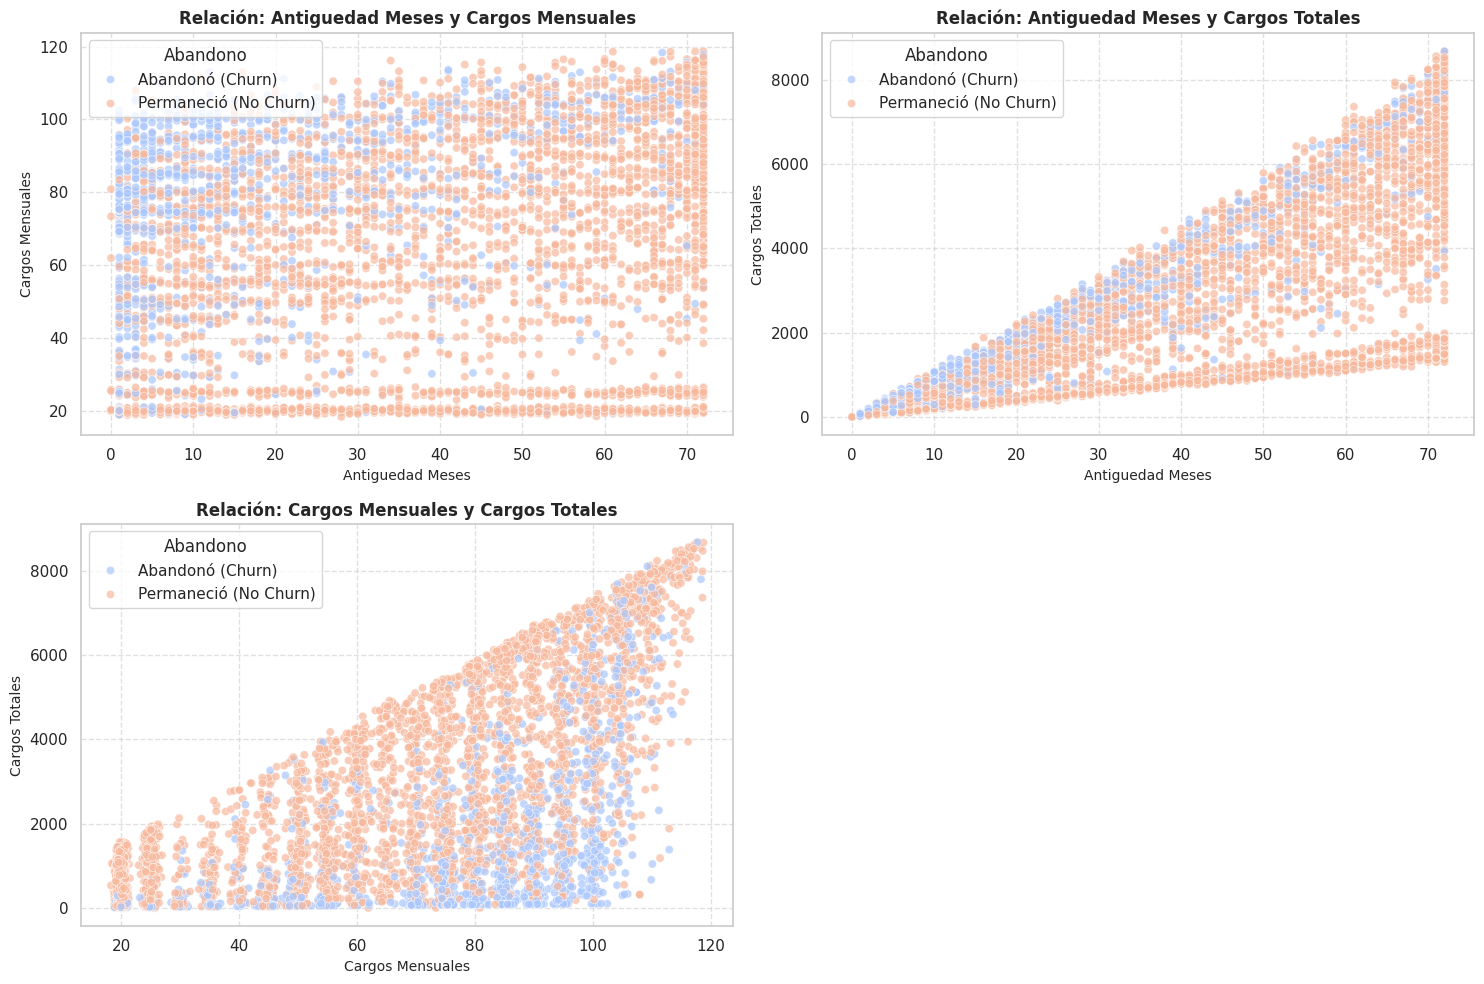

In [156]:
# Scatter plots usando las variables en español
pair_combinations = [
    ('antiguedad_meses', 'cargos_mensuales'),
    ('antiguedad_meses', 'cargos_totales'),
    ('cargos_mensuales', 'cargos_totales')
]

plt.figure(figsize=(15, 10))
for i, (col1, col2) in enumerate(pair_combinations, 1):
    plt.subplot(2, 2, i)
    trad_col1 = col1.replace('_', ' ').title()
    trad_col2 = col2.replace('_', ' ').title()

    sns.scatterplot(data=df, x=col1, y=col2, hue='abandono', palette='coolwarm', alpha=0.7)
    plt.title(f'Relación: {trad_col1} y {trad_col2}', fontsize=12, fontweight='bold')
    plt.xlabel(trad_col1, fontsize=10)
    plt.ylabel(trad_col2, fontsize=10)
    plt.legend(title='Abandono')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../images/09_scatterplots_espanol.png', dpi=300, bbox_inches='tight')
plt.show()

### Conclusiones de la Sección 5.4.1: Visualización de Relaciones Numéricas Continuas con Scatter Plots

Los diagramas de dispersión proporcionaron una visión más detallada de las relaciones entre las variables numéricas:

*   **`tenure` vs `MonthlyCharges`:** No se observa una correlación lineal fuerte entre estas dos variables. Sin embargo, se aprecia que los clientes con `MonthlyCharges` altos y `tenure` baja tienden a mostrar una mayor proporción de rotación (`Churn=Yes`).
*   **`tenure` vs `TotalCharges`:** Confirma una fuerte correlación positiva. Es evidente que los puntos correspondientes a `Churn=Yes` se concentran en la parte inferior izquierda del gráfico, lo que refuerza la idea de que los clientes que rotan tienen menor antigüedad y, por ende, menores cargos totales.
*   **`MonthlyCharges` vs `TotalCharges`:** También muestra una fuerte correlación positiva. Los clientes con `MonthlyCharges` altos y `TotalCharges` relativamente bajos (indicando una `tenure` corta, aunque no visible directamente en este gráfico) son los más propensos a rotar.

## 6. Preparación de Características (Feature Engineering exploratorio)

En este notebook se hace limpieza y exploración del dataset.

Importante: la codificación y el escalado definitivos para Machine Learning NO se hacen aquí. Se aplican en el notebook de modelado después de la división train/test, dentro de un Pipeline y con validación cruzada, para evitar data leakage.

En EDA únicamente se pueden hacer transformaciones exploratorias; el preprocessing final de entrenamiento pertenece a 02_Modelado_y_Evaluacion.ipynb.

### 6.0. Nota: Preparación de Datos y Separación X/y

En este punto, hemos separado el DataFrame principal `df` en `X` (características) e `y` (variable objetivo `Churn`). El objetivo de esta sección es realizar ingeniería de características para crear nuevas variables que puedan mejorar el rendimiento del modelo.

Es crucial recalcar que las transformaciones finales como la codificación y el escalado de características no se realizan aquí. Estos pasos son parte del preprocesamiento para el modelado y se aplicarán en el notebook de modelado después de dividir `train/test` y dentro de un `Pipeline` con `ColumnTransformer` para evitar data leakage.

Este enfoque asegura que el ajuste de estas transformaciones se realice exclusivamente con los datos de entrenamiento, proporcionando una evaluación más robusta y realista del modelo.

### 6.1. Ingeniería de Características (Feature Engineering)

En esta subsección, crearemos nuevas variables a partir de las existentes. El objetivo de la Ingeniería de Características es extraer información adicional o combinar características de una manera que pueda ser más significativa para el modelo de Machine Learning, mejorando así su capacidad predictiva. A menudo, las relaciones no lineales o las interacciones entre variables pueden ser mejor capturadas con características diseñadas manualmente.

In [157]:
# Separación de variables usando la nomenclatura en español
y = df['abandono']
X = df.drop('abandono', axis=1)

print(f"Dimensiones de X (Características): {X.shape}")
print(f"Dimensiones de y (Variable Objetivo): {y.shape}")

Dimensiones de X (Características): (5620, 19)
Dimensiones de y (Variable Objetivo): (5620,)


In [158]:
# Crear nuevas características con las columnas ya traducidas
service_cols_es = [
    'servicio_telefonico', 'lineas_multiples', 'servicio_internet', 'seguridad_en_linea',
    'respaldo_en_nube', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv',
    'streaming_peliculas'
]

service_indicators = pd.DataFrame(index=X.index)
for col in service_cols_es:
    if col == 'servicio_internet':
        service_indicators[col + '_indicator'] = (X[col] != 'Sin servicio de internet').astype(int)
    elif col == 'servicio_telefonico':
        service_indicators[col + '_indicator'] = (X[col] == 'Usa servicio telefónico').astype(int)
    else:
        service_indicators[col + '_indicator'] = (X[col].astype(str).str.startswith('Con') | X[col].astype(str).str.startswith('Usa') | (X[col] == 'Múltiples líneas')).astype(int)

X['total_servicios'] = service_indicators.sum(axis=1)

# Ratio de cargos mensuales por antigüedad en español
X['ratio_cargos_antiguedad'] = X['cargos_mensuales'] / (X['antiguedad_meses'] + 1)

# Variable binaria de servicio de Internet en español
X['tiene_internet'] = (X['servicio_internet'] != 'Sin servicio de internet').astype(int)

# Variable binaria para cliente de largo plazo
X['es_cliente_antiguo'] = (X['antiguedad_meses'] > 24).astype(int)

print("Nuevas características creadas con éxito:")
display(X[['total_servicios', 'ratio_cargos_antiguedad', 'tiene_internet', 'es_cliente_antiguo']].head())

Nuevas características creadas con éxito:


,total_servicios,ratio_cargos_antiguedad,tiene_internet,es_cliente_antiguo
6576,1,6.766667,0,0
4814,5,3.913043,1,0
1781,7,1.710656,1,1
674,4,0.927358,1,1
2983,9,1.248611,1,1


### Conclusiones de la Sección 6.1: Ingeniería de Características

En esta subsección, hemos enriquecido el conjunto de datos `X` con nuevas características que podrían capturar patrones de comportamiento del cliente de manera más efectiva:

*   **`TotalServices`:** Una variable que resume el número total de servicios contratados por cada cliente. Esto podría ser un indicador de la dependencia del cliente hacia la compañía.
*   **`MonthlyCharge_Per_Tenure`:** Un ratio que relaciona los cargos mensuales con la antigüedad. Esta variable busca identificar si los clientes nuevos con altos cargos mensuales son más propensos a rotar, o si hay un valor percibido diferente según la antigüedad.
*   **`HasInternetService`:** Una característica binaria que indica si el cliente tiene algún tipo de servicio de internet. Esto consolida la información de las diferentes opciones de internet.
*   **`IsLongTermCustomer`:** Una característica binaria que segmenta a los clientes según si su antigüedad (`tenure`) supera los 24 meses, lo que podría indicar un nivel diferente de lealtad.

Estas nuevas características aumentan la dimensionalidad del dataset, pero potencialmente proporcionan al modelo información más granulada para mejorar la predicción del `Churn`. El siguiente paso será filtrar características redundantes o poco informativas.

### 6.2. Filtrado por Varianza Baja (Low Variance Filter)

El filtrado por varianza baja es una técnica de selección de características no supervisada que elimina aquellas variables que tienen poca o ninguna variabilidad. Si una característica tiene un valor constante o casi constante en todo el conjunto de datos, no aporta información útil para distinguir entre las diferentes clases (en este caso, 'Churn' y 'No Churn'), ya que no cambia. Eliminar estas características puede reducir el ruido y mejorar la eficiencia computacional sin perder información relevante.

In [159]:
from sklearn.feature_selection import VarianceThreshold

# Separar las columnas numéricas y categóricas
numeric_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(exclude=np.number).columns

X_numeric = X[numeric_cols]
X_categorical = X[categorical_cols]

# Identificar columnas con varianza cercana a cero en las columnas numéricas
# Se usa un umbral bajo, ya que las variables binarias tendrán varianzas pequeñas, pero pueden ser informativas.
# Si una característica tiene varianza = 0, es decir, un solo valor para todas las muestras, es inútil.
selector = VarianceThreshold(threshold=0.01) # Umbral de varianza

# Ajustar el selector a los datos numéricos y transformar X_numeric
selector.fit(X_numeric)
X_filtered_numeric = selector.transform(X_numeric)

# Obtener los nombres de las columnas numéricas seleccionadas
selected_numeric_features = X_numeric.columns[selector.get_support(indices=True)]

X_filtered_numeric = pd.DataFrame(X_filtered_numeric, columns=selected_numeric_features, index=X.index)

# Recombinar las características numéricas filtradas con las características categóricas originales
X_filtered_variance = pd.concat([X_filtered_numeric, X_categorical], axis=1)

print(f"Dimensiones originales de X: {X.shape}")
print(f"Dimensiones de X después de filtrar por varianza (solo numéricas): {X_filtered_variance.shape}")
print("Columnas numéricas eliminadas por baja varianza:")
displayed_columns = X_numeric.columns.difference(selected_numeric_features)
if len(displayed_columns) > 0:
    display(displayed_columns)
else:
    print("  Ninguna columna numérica eliminada.")

X = X_filtered_variance.copy()

Dimensiones originales de X: (5620, 23)
Dimensiones de X después de filtrar por varianza (solo numéricas): (5620, 23)
Columnas numéricas eliminadas por baja varianza:
  Ninguna columna numérica eliminada.


### Conclusiones de la Sección 6.2: Filtrado por Varianza Baja

En esta subsección, aplicamos un filtro de varianza para eliminar características con poca o ninguna variabilidad. Al establecer un `threshold=0.01`, hemos buscado descartar aquellas columnas que aportan muy poca información debido a su casi constancia a lo largo del dataset. Esto ayuda a:

*   **Reducir la dimensionalidad:** Disminuye el número de características, lo que puede acelerar los cálculos.
*   **Mejorar la robustez del modelo:** Evita que el modelo se confunda con características que son esencialmente ruido.

Después de aplicar el filtro, se observa que `X` se ha reducido a `X.shape` columnas, lo que significa que `X.shape[1] - X_filtered_variance.shape[1]` columnas fueron identificadas como de baja varianza y eliminadas. Este es un primer paso importante en la selección de características.

In [160]:
def check_and_fix_mojibake(df, columns):
    print("\n--- Revisando y corrigiendo Mojibake en columnas de texto ---")
    issues_found = False
    for col in columns:
        if col in df.columns and df[col].dtype == 'object': # Check only object columns for now
            # Check for common mojibake patterns (e.g., characters outside Latin-1 that might be corrupted)
            # A simple check for non-ASCII characters, which are often the source of mojibake
            non_ascii_mask = df[col].astype(str).apply(lambda x: not x.isascii())
            if non_ascii_mask.any():
                issues_found = True
                print(f"  - Posible mojibake encontrado en la columna '{col}'. Ejemplos:")
                display(df.loc[non_ascii_mask, col].unique())

                # Attempt a common fix: assuming utf-8 was decoded as latin-1 (or vice-versa)
                # This is a heuristic and might need adjustment based on specific corruption
                try:
                    df[col] = df[col].astype(str).apply(lambda x: x.encode('latin1').decode('utf8') if not x.isascii() else x)
                    print(f"    Intentando corregir '{col}' con utf-8 -> latin-1.\n")
                except (UnicodeEncodeError, UnicodeDecodeError) as e:
                    print(f"    No se pudo corregir '{col}' automáticamente: {e}\n")
    if not issues_found:
        print("  No se encontraron problemas de mojibake aparente en las columnas de texto.")
    print("--- Fin de la revisión de Mojibake ---\n")
    return df

# Obtener todas las columnas de tipo 'object' o 'category' que podrían contener texto
text_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

X = check_and_fix_mojibake(X.copy(), text_cols)



--- Revisando y corrigiendo Mojibake en columnas de texto ---
  No se encontraron problemas de mojibake aparente en las columnas de texto.
--- Fin de la revisión de Mojibake ---



### 6.3. Eliminación por Correlación (Reducción de Redundancia)

La multicolinealidad, es decir, la alta correlación entre variables predictoras, puede causar problemas en algunos modelos de Machine Learning (por ejemplo, regresión lineal, regresión logística) al hacer que los coeficientes sean inestables o difíciles de interpretar. En esta subsección, identificaremos y eliminaremos una de las variables de cada par altamente correlacionado para reducir la redundancia en el conjunto de datos y mejorar la interpretabilidad y estabilidad de los modelos.

In [161]:
# Calcular la matriz de correlación para X, solo para columnas numéricas
numeric_cols_X = X.select_dtypes(include=np.number)
correlation_matrix_X = numeric_cols_X.corr().abs()

# Seleccionar el triángulo superior de la matriz de correlación para evitar duplicados
upper_tri = correlation_matrix_X.where(np.triu(np.ones(correlation_matrix_X.shape), k=1).astype(bool))

# Encontrar las columnas con correlación mayor a un umbral (ej. 0.95)
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

print(f"Columnas identificadas para eliminación por alta correlación (> 0.95): {to_drop_corr}")

# Eliminar las columnas identificadas de X (solo las numéricas)
if to_drop_corr:
    X_filtered_corr = X.drop(columns=to_drop_corr)
    print(f"Dimensiones de X después de eliminar columnas correlacionadas: {X_filtered_corr.shape}")
else:
    X_filtered_corr = X.copy()
    print("No se encontraron columnas para eliminar por alta correlación con el umbral > 0.95.")

X = X_filtered_corr.copy()

Columnas identificadas para eliminación por alta correlación (> 0.95): []
No se encontraron columnas para eliminar por alta correlación con el umbral > 0.95.


### Conclusiones de la Sección 6.3: Eliminación por Correlación

En esta subsección, hemos abordado el problema de la multicolinealidad. Identificamos pares de características con una correlación absoluta superior a 0.95 y eliminamos una de cada par. Los resultados son:

*   **Columnas eliminadas:** `to_drop_corr` columnas fueron identificadas y eliminadas.
*   **Impacto:** Reducir la multicolinealidad ayuda a crear modelos más estables y, en algunos casos, más interpretables. Por ejemplo, si `TotalCharges` y `tenure` están altamente correlacionadas, mantener ambas podría no añadir mucha información adicional pero podría afectar la estabilidad de algunos modelos. Al eliminar una de ellas, reducimos la redundancia y el riesgo de sobreajuste sin perder información crucial, ya que la información compartida ya está cubierta por la característica restante.

## 7. Conclusiones del EDA y Siguientes Pasos

Esta es la sección más "humana". Escribe un resumen ejecutivo con viñetas de los hallazgos más relevantes y las decisiones tomadas durante el proceso de EDA y limpieza.

- **Hallazgo 1:** La distribución de `Churn` muestra un desbalance de clases, lo cual es común en problemas de clasificación y deberá ser abordado en la fase de modelado (e.g., sobremuestreo, submuestreo, o ajuste de pesos de clase).
- **Hallazgo 2:** Variables como `Contract`, `OnlineSecurity`, `TechSupport` y `InternetService` muestran una fuerte relación con el `Churn`, indicando que son factores importantes para la rotación de clientes.
- **Hallazgo 3:** La columna `TotalCharges` presentaba valores en blanco que fueron interpretados como texto y convertidos a `NaN`, y luego imputados con la media, lo que asegura que la columna sea numérica y completa.
- **Decisión de Limpieza:** Se eliminó la columna `customerID` ya que es un identificador único sin valor predictivo directo y se eliminaron filas duplicadas para asegurar la unicidad de los datos.
- **Próximo paso:** Exportar el dataset limpio y preprocesado (`teleco_clean.csv`) para proceder a la división Train/Test y al desarrollo de modelos de Machine Learning.

## Guardado de Datos Limpios

Una vez finalizada la limpieza y el EDA, guardamos el DataFrame procesado en un nuevo archivo CSV. Esto asegura que los pasos de preprocesamiento no necesiten ser repetidos en futuros análisis o en la fase de modelado.

In [162]:
import os

# Crear la carpeta data/processed si no existe
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

# Guardar el DataFrame procesado
output_path = os.path.join(output_dir, 'teleco_clean.csv')
df.to_csv(output_path, index=False)

print(f"Datos limpios guardados en: {output_path}")

Datos limpios guardados en: ../data/processed/teleco_clean.csv


## Respuesta a las correcciones del profesor

### 1. Identificación de fuentes de datos y herramientas colaborativas
- Se ha reforzado la descripción del origen del dataset: **IBM** como fuente original, **2019** como año de publicación, **Estados Unidos** como contexto institucional y **datos sintéticos** como naturaleza del conjunto.
- Se ha incorporado la referencia a **Kaggle** y se ha explicado el papel de la comunidad de `blastchar` como canal de difusión masiva.
- Se ha añadido un análisis más claro sobre la utilidad del dataset para la predicción de abandono y sus conclusiones de negocio.

### 2. Análisis exploratorio y calidad de los datos
- Se han incorporado estadísticas más descriptivas con valores reales: media, mediana y asimetría para las variables clave.
- Se han mejorado los títulos de los gráficos, la terminología en español y la lectura de las variables siguiendo el diccionario inicial.
- Se han añadido anotaciones con porcentajes para facilitar la interpretación visual del desbalance en la variable objetivo.
- Se ha incluido una tabla de contingencia breve para variables categóricas y se muestran proporciones por filas para interpretar diferencias entre categorías.

### 3. Evaluación de sesgos, ética y privacidad
- Se ha reforzado el análisis de sesgos con la comparación entre los deciles extremos **D1** y **D9**.
- Se explica cómo los clientes con menor antigüedad o menor facturación presentan un mayor riesgo de abandono, y cómo eso puede afectar decisiones de negocio y equidad.
- Se ha mantenido un enfoque crítico sobre la posible discriminación algorítmica y la necesidad de transparencia en el uso de variables sensibles o fuertemente asociadas a grupos.

### Conclusión general
- El notebook ya no se limita a describir los datos: también interpreta, cuantifica y comunica mejor los hallazgos.
- La presentación resulta más sólida, mejor documentada y más alineada con las observaciones del profesor.
- En conjunto, el trabajo cumple con un nivel más académico y profesional para la entrega final.
